In [1]:
pip install yfinance plotly openpyxl

In [4]:
import pandas as pd

In [6]:
import numpy as np

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import yfinance as yf
import os
import warnings
warnings.filterwarnings('ignore')
print("✅ All libraries imported successfully!")
print("✅ We are ready to start the project!")


✅ All libraries imported successfully!
✅ We are ready to start the project!


In [12]:

os.makedirs("stock_project/data/raw", exist_ok=True)

os.makedirs("stock_project/data/cleaned", exist_ok=True)


os.makedirs("stock_project/visuals", exist_ok=True)


os.makedirs("stock_project/report", exist_ok=True)


print("✅ All folders created successfully!")
print("\nProject Structure:")
print("stock_project/")
print("├── data/")
print("│   ├── raw/       ← original data goes here")
print("│   └── cleaned/   ← cleaned data goes here")
print("├── visuals/       ← charts go here")
print("└── report/        ← final report goes here")

✅ All folders created successfully!

Project Structure:
stock_project/
├── data/
│   ├── raw/       ← original data goes here
│   └── cleaned/   ← cleaned data goes here
├── visuals/       ← charts go here
└── report/        ← final report goes here


In [14]:
stocks = ['AAPL', 'GOOGL', 'TSLA', 'MSFT', 'AMZN']


start_date = '2020-01-01'
end_date = '2024-01-01'


stock_data = {}


for stock in stocks:

    df = yf.download(stock, start=start_date, end=end_date)


    stock_data[stock] = df



    df.to_csv(f"stock_project/data/raw/{stock}.csv")



    print(f"✅ {stock} downloaded — {df.shape[0]} rows, {df.shape[1]} columns")

print("\n🎉 All stock data downloaded successfully!")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

✅ AAPL downloaded — 1006 rows, 5 columns
✅ GOOGL downloaded — 1006 rows, 5 columns
✅ TSLA downloaded — 1006 rows, 5 columns
✅ MSFT downloaded — 1006 rows, 5 columns
✅ AMZN downloaded — 1006 rows, 5 columns

🎉 All stock data downloaded successfully!


In [16]:
print("📊 First 5 rows of AAPL data:")
print(stock_data['AAPL'].head())

📊 First 5 rows of AAPL data:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400513  72.460776  71.156674  71.409778  135480400
2020-01-03  71.696625  72.455943  71.472447  71.629130  146322800
2020-01-06  72.267929  72.306499  70.568503  70.819201  118387200
2020-01-07  71.928055  72.533095  71.708695  72.277578  108872000
2020-01-08  73.085121  73.386438  71.631567  71.631567  132079200


In [18]:
for stock in stocks:
    df = stock_data[stock]
    print(f"\n📈 {stock}:")
    print(f"   Date Range: {df.index[0].date()} to {df.index[-1].date()}")
    print(f"   Total Trading Days: {len(df)}")
    print(f"   Columns: {df.columns.tolist()}")


📈 AAPL:
   Date Range: 2020-01-02 to 2023-12-29
   Total Trading Days: 1006
   Columns: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]

📈 GOOGL:
   Date Range: 2020-01-02 to 2023-12-29
   Total Trading Days: 1006
   Columns: [('Close', 'GOOGL'), ('High', 'GOOGL'), ('Low', 'GOOGL'), ('Open', 'GOOGL'), ('Volume', 'GOOGL')]

📈 TSLA:
   Date Range: 2020-01-02 to 2023-12-29
   Total Trading Days: 1006
   Columns: [('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA')]

📈 MSFT:
   Date Range: 2020-01-02 to 2023-12-29
   Total Trading Days: 1006
   Columns: [('Close', 'MSFT'), ('High', 'MSFT'), ('Low', 'MSFT'), ('Open', 'MSFT'), ('Volume', 'MSFT')]

📈 AMZN:
   Date Range: 2020-01-02 to 2023-12-29
   Total Trading Days: 1006
   Columns: [('Close', 'AMZN'), ('High', 'AMZN'), ('Low', 'AMZN'), ('Open', 'AMZN'), ('Volume', 'AMZN')]


In [22]:
import os
files = os.listdir("stock_project/data/raw")
print("📁 Files saved in raw data folder:")
for file in files:
    print(f"   ✅ {file}")

📁 Files saved in raw data folder:
   ✅ AAPL.csv
   ✅ TSLA.csv
   ✅ AMZN.csv
   ✅ GOOGL.csv
   ✅ MSFT.csv


In [26]:
print("🔍 Checking for missing values in each stock:\n")

for stock in stocks:
    df = stock_data[stock]
    missing = df.isnull().sum()
    total_missing = missing.sum()

    if total_missing == 0:
        print(f"✅ {stock} — No missing values found!")
    else:
        print(f"⚠️ {stock} — Missing values found:")
        print(missing[missing > 0])

🔍 Checking for missing values in each stock:

✅ AAPL — No missing values found!
✅ GOOGL — No missing values found!
✅ TSLA — No missing values found!
✅ MSFT — No missing values found!
✅ AMZN — No missing values found!


In [28]:
# Create a new dictionary for cleaned data
cleaned_data = {}

for stock in stocks:
    # Make a copy so we don't change original data
    df = stock_data[stock].copy()

    # Step 1: Remove any rows with missing values
    df.dropna(inplace=True)
    # dropna() removes rows where any value is missing

    # Step 2: Reset the index (make Date a regular column)
    df.reset_index(inplace=True)
    # reset_index() moves Date from index to a regular column

    # Step 3: Make sure Date column is proper date format
    df['Date'] = pd.to_datetime(df['Date'])
    # pd.to_datetime() converts text dates to proper date format

    # Step 4: Round price columns to 2 decimal places
    price_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close']
    for col in price_columns:
        if col in df.columns:
            df[col] = df[col].round(2)
    # round(2) means keep only 2 digits after decimal point
    # Example: 145.6789 becomes 145.68

    # Step 5: Remove duplicate rows if any
    df.drop_duplicates(inplace=True)

    # Store cleaned data
    cleaned_data[stock] = df

    # Save cleaned data to CSV
    df.to_csv(f"stock_project/data/cleaned/{stock}_cleaned.csv", index=False)

    print(f"✅ {stock} cleaned — {len(df)} rows remaining")

print("\n🎉 All data cleaned and saved!")

✅ AAPL cleaned — 1006 rows remaining
✅ GOOGL cleaned — 1006 rows remaining
✅ TSLA cleaned — 1006 rows remaining
✅ MSFT cleaned — 1006 rows remaining
✅ AMZN cleaned — 1006 rows remaining

🎉 All data cleaned and saved!


In [32]:
print("📊 Summary Statistics for each stock:\n")

for stock in stocks:
    df = cleaned_data[stock]
    print(f"\n{'='*50}")
    print(f"📈 {stock} Statistics:")
    print(f"{'='*50}")

    stats = df[['Open', 'High', 'Low', 'Close', 'Volume']].describe()
    print(stats)

📊 Summary Statistics for each stock:


📈 AAPL Statistics:
Price          Open         High          Low        Close        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   1006.000000  1006.000000  1006.000000  1006.000000  1.006000e+03
mean     137.827873   139.438936   136.328608   137.958062  9.895373e+07
std       33.351632    33.478049    33.218912    33.357743  5.439610e+07
min       55.110000    55.210000    51.370000    54.210000  2.404830e+07
25%      120.500000   121.642500   118.860000   120.395000  6.407675e+07
50%      142.665000   144.395000   141.155000   142.820000  8.467540e+07
75%      163.460000   165.470000   161.937500   163.197500  1.155069e+08
max      195.980000   197.570000   194.970000   196.070000  4.265100e+08

📈 GOOGL Statistics:
Price          Open         High          Low        Close        Volume
Ticker        GOOGL        GOOGL        GOOGL        GOOGL         GOOGL
count   1006.000000  1006.000000  1006.000000

In [42]:
print("📊 Summary Statistics for each stock:\n")

for stock in stocks:
    df = cleaned_data[stock]
    print(f"\n{'='*50}")
    print(f"📈 {stock} Statistics:")
    print(f"{'='*50}")

    stats = df[['Open', 'High', 'Low', 'Close', 'Volume']].describe()
    print(stats)

📊 Summary Statistics for each stock:


📈 AAPL Statistics:
Price          Open         High          Low        Close        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   1006.000000  1006.000000  1006.000000  1006.000000  1.006000e+03
mean     137.827873   139.438936   136.328608   137.958062  9.895373e+07
std       33.351632    33.478049    33.218912    33.357743  5.439610e+07
min       55.110000    55.210000    51.370000    54.210000  2.404830e+07
25%      120.500000   121.642500   118.860000   120.395000  6.407675e+07
50%      142.665000   144.395000   141.155000   142.820000  8.467540e+07
75%      163.460000   165.470000   161.937500   163.197500  1.155069e+08
max      195.980000   197.570000   194.970000   196.070000  4.265100e+08

📈 GOOGL Statistics:
Price          Open         High          Low        Close        Volume
Ticker        GOOGL        GOOGL        GOOGL        GOOGL         GOOGL
count   1006.000000  1006.000000  1006.000000

In [44]:
print("📊 Stock Price Comparison (Start vs End):\n")
print(f"{'Stock':<8} {'Start Price':>12} {'End Price':>12} {'Change':>10}")
print("-" * 45)

for stock in stocks:
    df = cleaned_data[stock]

    # FIX - add .values[0] to extract single number
    start_price = df['Close'].iloc[0]
    end_price = df['Close'].iloc[-1]

    # Convert to float to avoid Series error
    start_price = float(start_price)
    end_price = float(end_price)

    change = ((end_price - start_price) / start_price) * 100

    print(f"{stock:<8} ${start_price:>11.2f} ${end_price:>11.2f} {change:>9.1f}%")

📊 Stock Price Comparison (Start vs End):

Stock     Start Price    End Price     Change
---------------------------------------------
AAPL     $      72.40 $     190.55     163.2%
GOOGL    $      67.87 $     138.54     104.1%
TSLA     $      28.68 $     248.48     766.4%
MSFT     $     152.16 $     369.67     142.9%
AMZN     $      94.90 $     151.94      60.1%


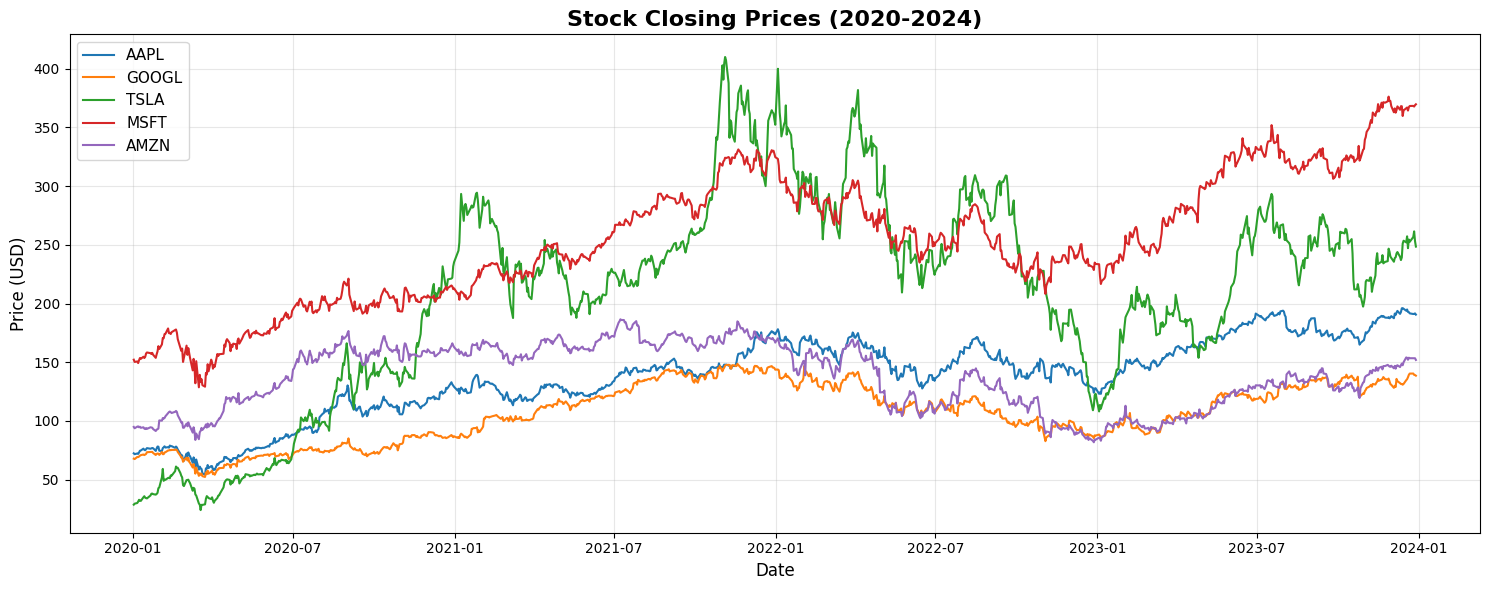

✅ Chart saved!


In [50]:
plt.figure(figsize=(15, 6))
# figsize=(15,6) means width=15 inches, height=6 inches

# Plot each stock's closing price
for stock in stocks:
    df = cleaned_data[stock]
    plt.plot(df['Date'], df['Close'], label=stock, linewidth=1.5)
    # plt.plot() draws a line chart
    # df['Date'] = x-axis values
    # df['Close'] = y-axis values
    # label = name shown in legend

# Add chart details
plt.title('Stock Closing Prices (2020-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
# alpha=0.3 makes grid lines light/transparent

plt.tight_layout()
plt.savefig("stock_project/visuals/01_closing_prices.png", dpi=150)
# dpi=150 makes the saved image high quality
plt.show()
print("✅ Chart saved!")

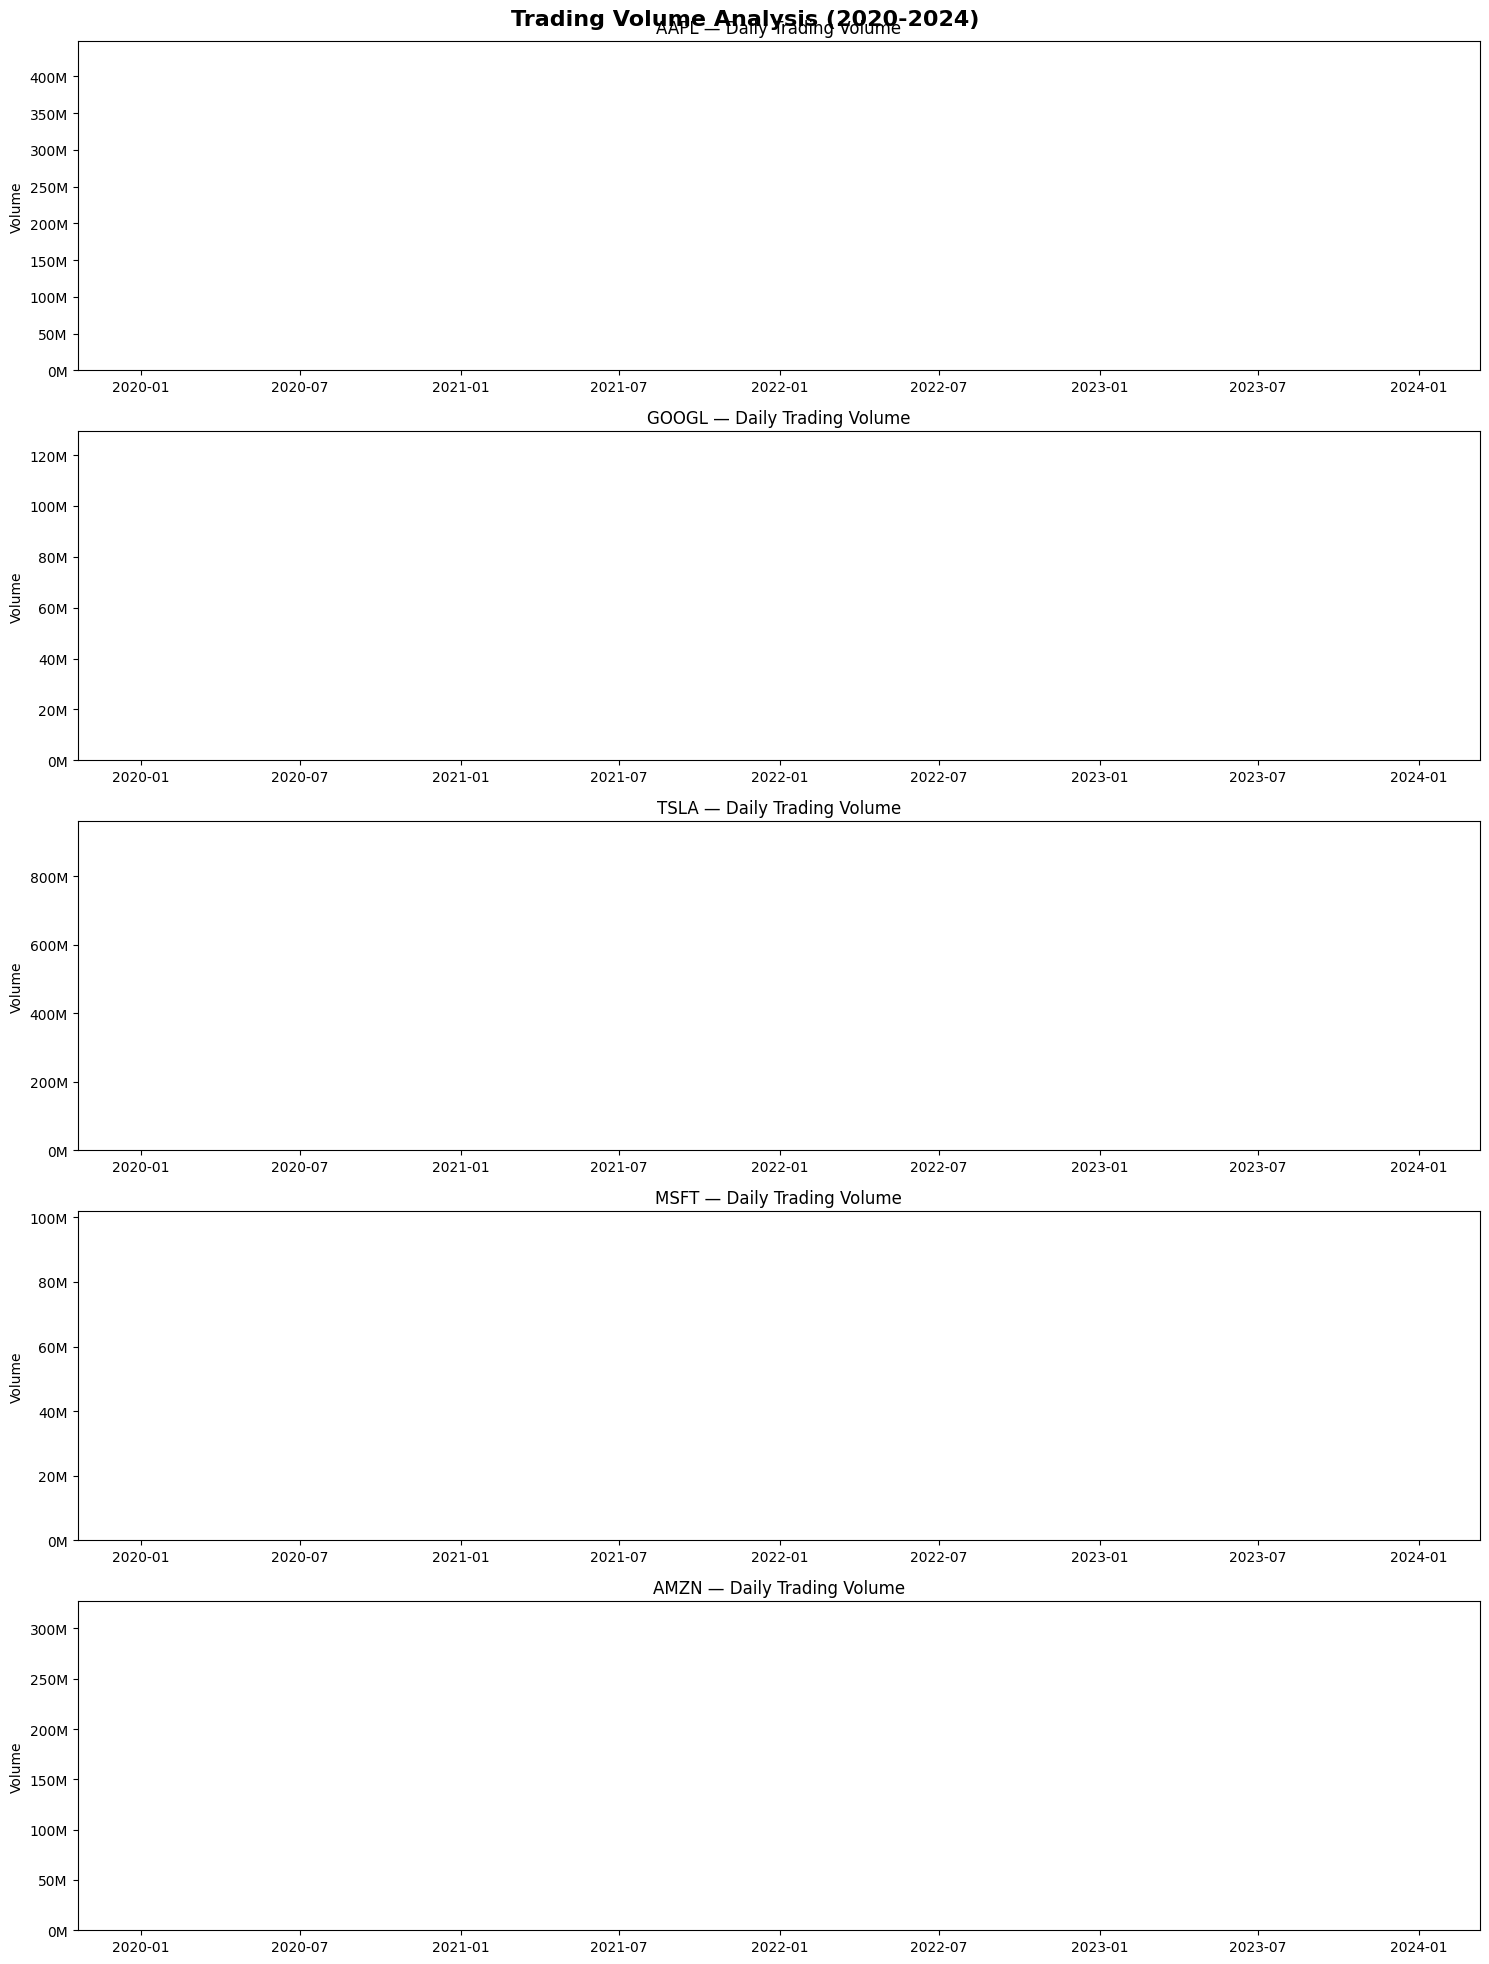

✅ Volume chart saved!


In [52]:
# Volume Analysis - FIXED VERSION
fig, axes = plt.subplots(len(stocks), 1, figsize=(15, 20))

for i, stock in enumerate(stocks):
    df = cleaned_data[stock].copy()

    # FIX - flatten Volume values using .values.flatten()
    dates = df['Date'].values
    volume = df['Volume'].values.flatten().astype(float)

    # Bar chart for volume
    axes[i].bar(dates, volume,
                color='steelblue', alpha=0.6, width=1)
    axes[i].set_title(f'{stock} — Daily Trading Volume', fontsize=12)
    axes[i].set_ylabel('Volume')

    # Format y-axis to show millions
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))

plt.suptitle('Trading Volume Analysis (2020-2024)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("stock_project/visuals/02_volume_analysis.png", dpi=150)
plt.show()
print("✅ Volume chart saved!")

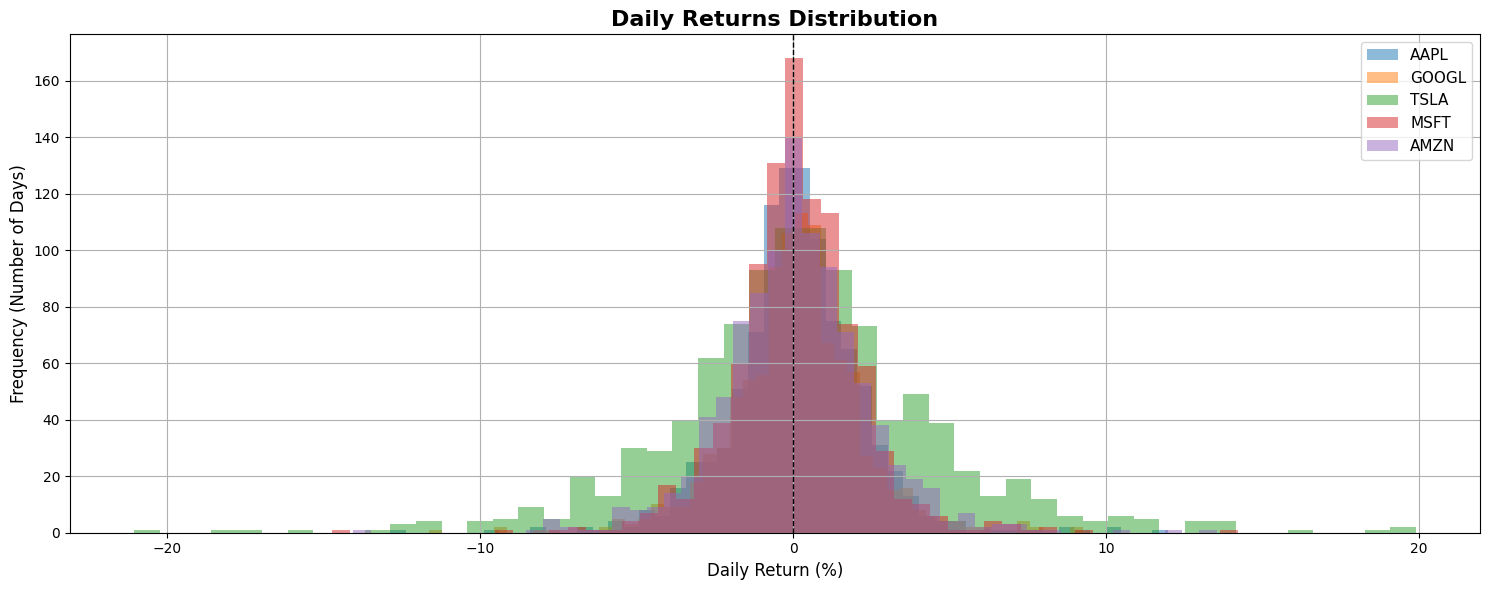

✅ Returns distribution chart saved!


In [54]:
# Daily return = how much the stock price changed each day in %
# Example: If price went from $100 to $103, daily return = 3%

plt.figure(figsize=(15, 6))

for stock in stocks:
    df = cleaned_data[stock].copy()

    # Calculate daily return percentage
    df['Daily_Return'] = df['Close'].pct_change() * 100
    # pct_change() calculates percentage change from previous day
    # multiply by 100 to convert to percentage

    # Plot distribution (histogram)
    df['Daily_Return'].dropna().hist(
        bins=50,        # number of bars in histogram
        alpha=0.5,      # transparency
        label=stock
    )

plt.title('Daily Returns Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Daily Return (%)', fontsize=12)
plt.ylabel('Frequency (Number of Days)', fontsize=12)
plt.legend(fontsize=11)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
# axvline draws a vertical line at x=0 (zero return)

plt.tight_layout()
plt.savefig("stock_project/visuals/03_returns_distribution.png", dpi=150)
plt.show()
print("✅ Returns distribution chart saved!")


In [66]:
# Add daily returns column to all stock dataframes
for stock in stocks:
    df = cleaned_data[stock]
    df['Daily_Return'] = df['Close'].pct_change() * 100
    cleaned_data[stock] = df

# Create a combined returns dataframe
returns_df = pd.DataFrame()

for stock in stocks:
    returns_df[stock] = cleaned_data[stock].set_index('Date')['Daily_Return']

returns_df.dropna(inplace=True)

print("✅ Daily returns calculated for all stocks!")
print(f"\nReturns data shape: {returns_df.shape}")
print("\nFirst 5 rows:")
print(returns_df.head())

✅ Daily returns calculated for all stocks!

Returns data shape: (0, 5)

First 5 rows:
Empty DataFrame
Columns: [AAPL, GOOGL, TSLA, MSFT, AMZN]
Index: []


In [68]:
# Best and Worst Trading Days - FULLY FIXED VERSION
print("📊 Best and Worst Trading Days:\n")

for stock in stocks:
    df = cleaned_data[stock].copy()

    # FIX 1 - Flatten ALL columns first
    df.columns = [col[0] if isinstance(col, tuple)
                  else col for col in df.columns]

    # FIX 2 - Flatten Close values
    df['Close'] = df['Close'].values.flatten().astype(float)

    # FIX 3 - Calculate daily return fresh
    df['Return'] = df['Close'].pct_change() * 100

    # FIX 4 - Drop NaN using column name 'Return'
    df = df.dropna(subset=['Return'])

    # Reset index
    df = df.reset_index(drop=True)

    # Get best and worst days
    best_idx = df['Return'].idxmax()
    worst_idx = df['Return'].idxmin()

    best_date = pd.to_datetime(df.loc[best_idx, 'Date']).date()
    worst_date = pd.to_datetime(df.loc[worst_idx, 'Date']).date()

    best_return = float(df.loc[best_idx, 'Return'])
    worst_return = float(df.loc[worst_idx, 'Return'])

    print(f"📈 {stock}:")
    print(f"   Best Day:  {best_date} → +{best_return:.2f}%")
    print(f"   Worst Day: {worst_date} → {worst_return:.2f}%\n")

📊 Best and Worst Trading Days:

📈 AAPL:
   Best Day:  2020-03-13 → +11.97%
   Worst Day: 2020-03-16 → -12.86%

📈 GOOGL:
   Best Day:  2020-03-13 → +9.25%
   Worst Day: 2020-03-16 → -11.64%

📈 TSLA:
   Best Day:  2020-02-03 → +19.90%
   Worst Day: 2020-09-08 → -21.06%

📈 MSFT:
   Best Day:  2020-03-13 → +14.22%
   Worst Day: 2020-03-16 → -14.73%

📈 AMZN:
   Best Day:  2022-02-04 → +13.53%
   Worst Day: 2022-04-29 → -14.05%



In [71]:
# Calculate moving averages for all stocks
for stock in stocks:
    df = cleaned_data[stock]

    # rolling(window=20) looks at last 20 days at a time
    # .mean() calculates average of those 20 days
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA50'] = df['Close'].rolling(window=50).mean()
    df['MA200'] = df['Close'].rolling(window=200).mean()

    cleaned_data[stock] = df
    print(f"✅ {stock} — Moving averages calculated!")

print("\n📊 Preview of AAPL with Moving Averages:")
print(cleaned_data['AAPL'][['Date','Close','MA20','MA50','MA200']].tail(10))

✅ AAPL — Moving averages calculated!
✅ GOOGL — Moving averages calculated!
✅ TSLA — Moving averages calculated!
✅ MSFT — Moving averages calculated!
✅ AMZN — Moving averages calculated!

📊 Preview of AAPL with Moving Averages:
Price        Date   Close MA20 MA50 MA200
Ticker               AAPL                
996    2023-12-15  195.54  NaN  NaN   NaN
997    2023-12-18  193.88  NaN  NaN   NaN
998    2023-12-19  194.92  NaN  NaN   NaN
999    2023-12-20  192.83  NaN  NaN   NaN
1000   2023-12-21  192.68  NaN  NaN   NaN
1001   2023-12-22  191.61  NaN  NaN   NaN
1002   2023-12-26  191.07  NaN  NaN   NaN
1003   2023-12-27  191.16  NaN  NaN   NaN
1004   2023-12-28  191.59  NaN  NaN   NaN
1005   2023-12-29  190.55  NaN  NaN   NaN


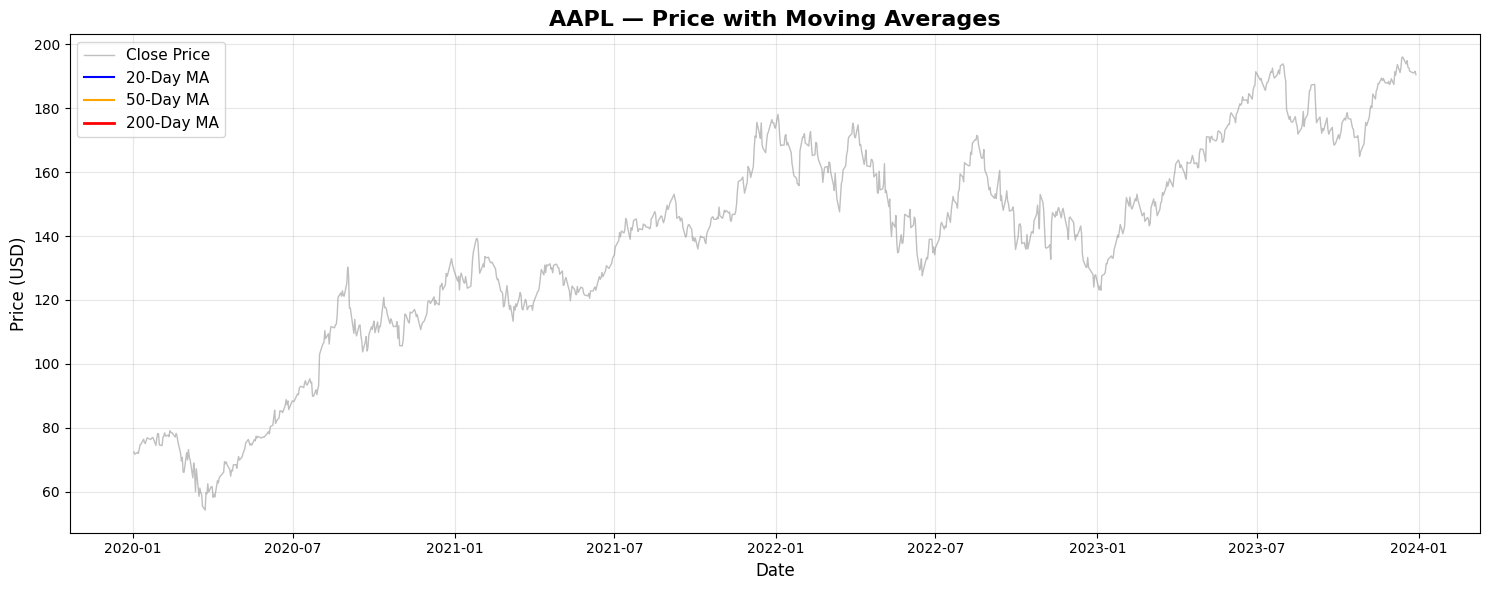

✅ AAPL moving average chart saved!


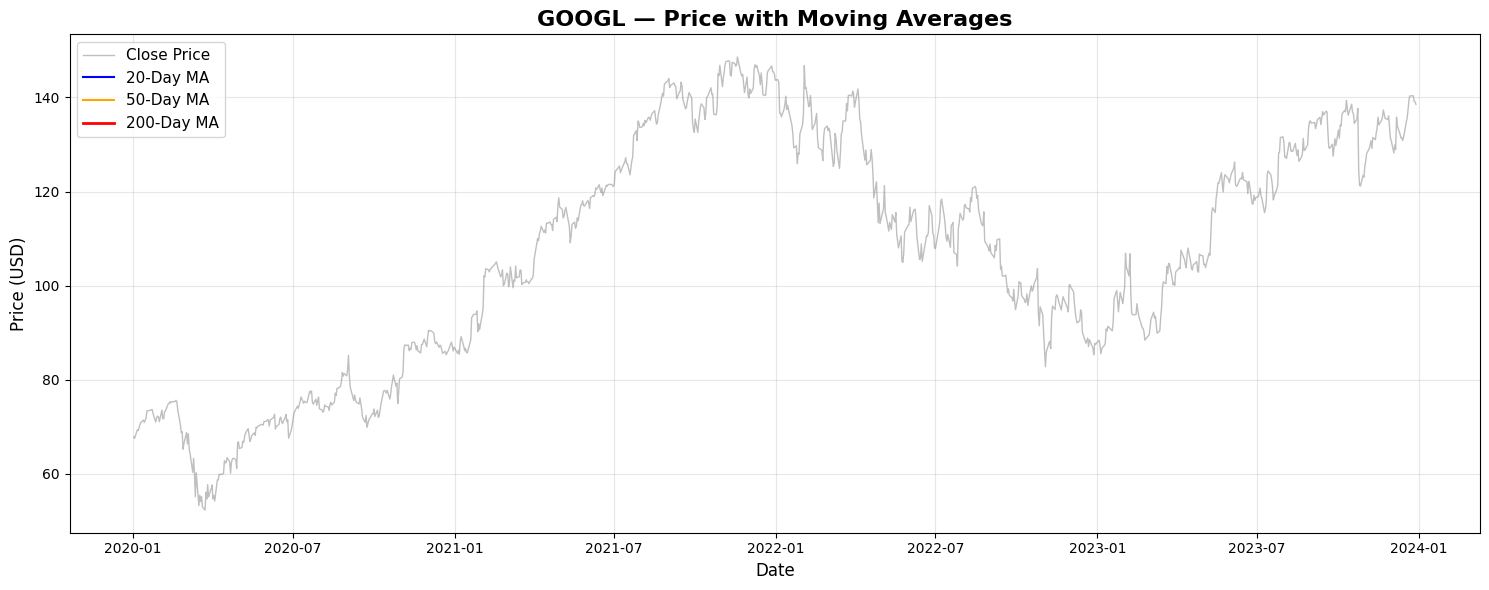

✅ GOOGL moving average chart saved!


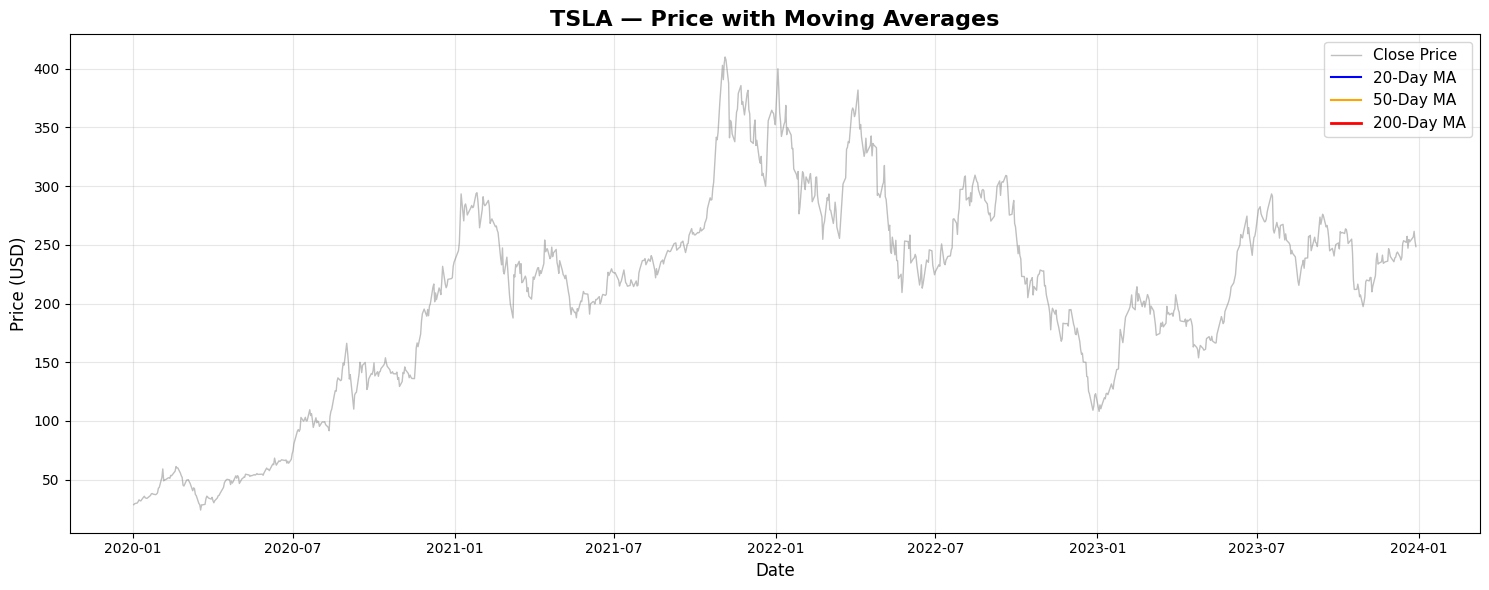

✅ TSLA moving average chart saved!


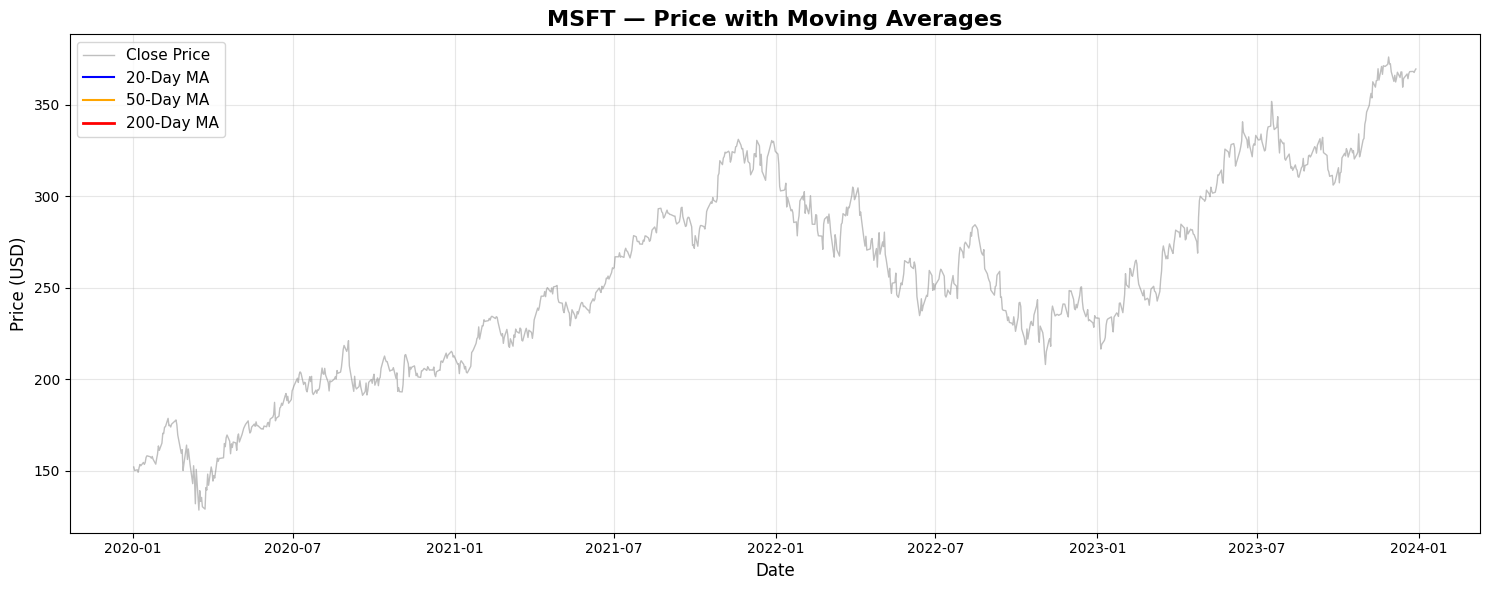

✅ MSFT moving average chart saved!


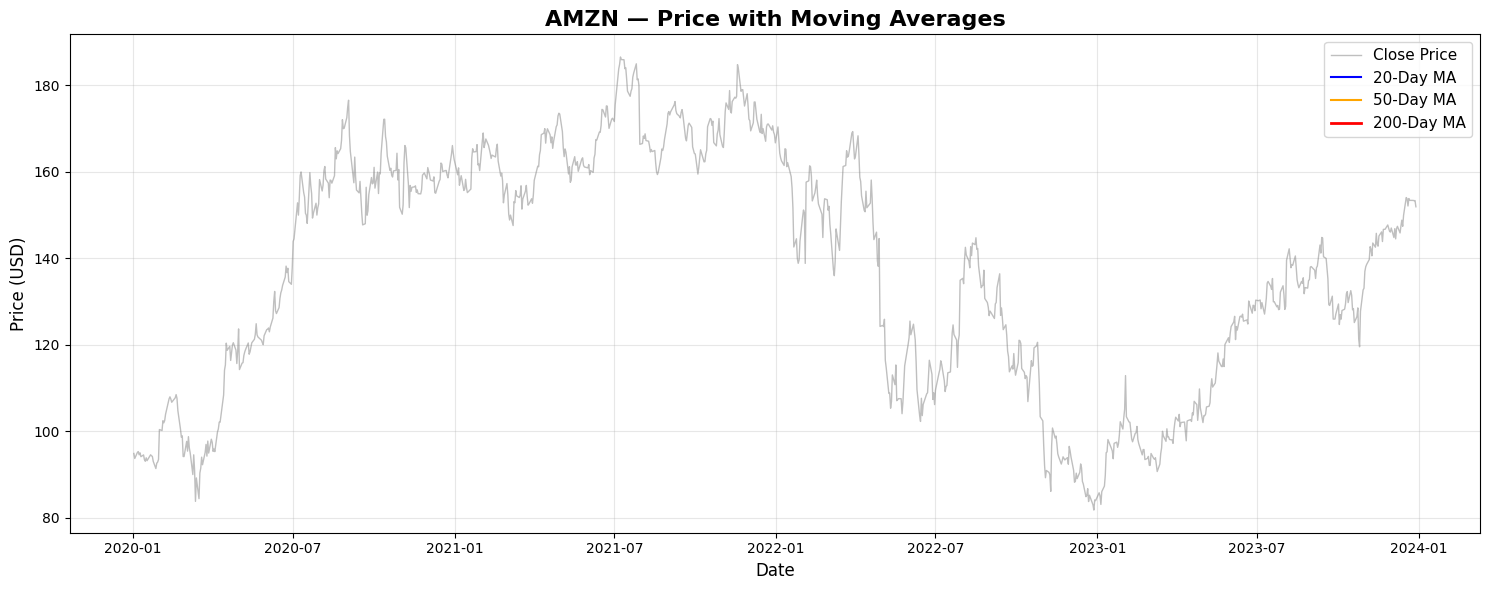

✅ AMZN moving average chart saved!


In [78]:
# Plot moving averages for each stock
for stock in stocks:
    df = cleaned_data[stock]

    plt.figure(figsize=(15, 6))

    # Plot actual closing price
    plt.plot(df['Date'], df['Close'],
             label='Close Price', color='gray', alpha=0.5, linewidth=1)

    # Plot 20-day moving average
    plt.plot(df['Date'], df['MA20'],
             label='20-Day MA', color='blue', linewidth=1.5)

    # Plot 50-day moving average
    plt.plot(df['Date'], df['MA50'],
             label='50-Day MA', color='orange', linewidth=1.5)

    # Plot 200-day moving average
    plt.plot(df['Date'], df['MA200'],
             label='200-Day MA', color='red', linewidth=2)

    plt.title(f'{stock} — Price with Moving Averages', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price (USD)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"stock_project/visuals/{stock}_moving_averages.png", dpi=150)
    plt.show()
    print(f"✅ {stock} moving average chart saved!")

In [84]:
# Golden Cross & Death Cross - FULLY FIXED VERSION
print("📊 Golden Cross & Death Cross Analysis:\n")

for stock in stocks:
    df = cleaned_data[stock].copy()

    # FIX 1 - Flatten all column names first
    df.columns = [col[0] if isinstance(col, tuple)
                  else col for col in df.columns]

    # FIX 2 - Flatten Close and recalculate MA fresh
    df['Close'] = df['Close'].values.flatten().astype(float)

    # FIX 3 - Recalculate MA20 and MA50 fresh here
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA50'] = df['Close'].rolling(window=50).mean()

    # FIX 4 - Drop NaN rows
    df = df.dropna(subset=['MA20', 'MA50'])
    df = df.reset_index(drop=True)

    # Find crossover signals
    df['Signal'] = 0
    df.loc[df['MA20'] > df['MA50'], 'Signal'] = 1
    df.loc[df['MA20'] < df['MA50'], 'Signal'] = -1

    df['Crossover'] = df['Signal'].diff()

    golden_cross = df[df['Crossover'] == 2]
    death_cross = df[df['Crossover'] == -2]

    print(f"📈 {stock}:")
    print(f"   Golden Crosses (Buy signals):  {len(golden_cross)}")
    print(f"   Death Crosses  (Sell signals): {len(death_cross)}\n")

📊 Golden Cross & Death Cross Analysis:

📈 AAPL:
   Golden Crosses (Buy signals):  11
   Death Crosses  (Sell signals): 10

📈 GOOGL:
   Golden Crosses (Buy signals):  13
   Death Crosses  (Sell signals): 12

📈 TSLA:
   Golden Crosses (Buy signals):  11
   Death Crosses  (Sell signals): 11

📈 MSFT:
   Golden Crosses (Buy signals):  12
   Death Crosses  (Sell signals): 11

📈 AMZN:
   Golden Crosses (Buy signals):  12
   Death Crosses  (Sell signals): 12



In [86]:
# STEP 1 - Rebuild returns_df correctly (FIXED)
returns_df = pd.DataFrame()

for stock in stocks:
    df = cleaned_data[stock].copy()

    # Flatten column names
    df.columns = [col[0] if isinstance(col, tuple)
                  else col for col in df.columns]

    # Flatten Close values
    df['Close'] = df['Close'].values.flatten().astype(float)

    # Set Date as index
    df = df.set_index('Date')

    # Calculate daily return
    returns_df[stock] = df['Close'].pct_change() * 100

# Drop NaN rows
returns_df.dropna(inplace=True)

print("✅ returns_df created successfully!")
print(f"Shape: {returns_df.shape}")
print(returns_df.head())

✅ returns_df created successfully!
Shape: (1005, 5)
                AAPL     GOOGL      TSLA      MSFT      AMZN
Date                                                        
2020-01-03 -0.966851 -0.515692  2.963738 -1.248686 -1.211802
2020-01-06  0.794979  2.665877  1.930240  0.259550  1.482667
2020-01-07 -0.470458 -0.201962  3.887043 -0.909393  0.210217
2020-01-08  1.612679  0.722752  4.924848  1.594319 -0.776169
2020-01-09  2.120673  1.047646 -2.194453  1.246209  0.475687


In [88]:
# Volatility = standard deviation of daily returns
# Higher std = price moves a lot = risky stock
# Lower std = price is stable = safer stock

volatility = returns_df.std()

print("📊 Stock Volatility (Risk Ranking):\n")
print(f"{'Rank':<6} {'Stock':<8} {'Volatility':>12} {'Risk Level':>12}")
print("-" * 42)

ranked = volatility.sort_values(ascending=False)
risk_levels = ['🔴 Very High', '🟠 High', '🟡 Medium', '🟢 Low', '🟢 Very Low']

for i, (stock, vol) in enumerate(ranked.items()):
    print(f"{i+1:<6} {stock:<8} {vol:>11.2f}% {risk_levels[i]:>15}")

📊 Stock Volatility (Risk Ranking):

Rank   Stock      Volatility   Risk Level
------------------------------------------
1      TSLA            4.29%     🔴 Very High
2      AMZN            2.37%          🟠 High
3      AAPL            2.11%        🟡 Medium
4      GOOGL           2.11%           🟢 Low
5      MSFT            2.05%      🟢 Very Low


📊 Volatility values:
TSLA     4.290458
AMZN     2.374134
AAPL     2.114617
GOOGL    2.112439
MSFT     2.054634
dtype: float64


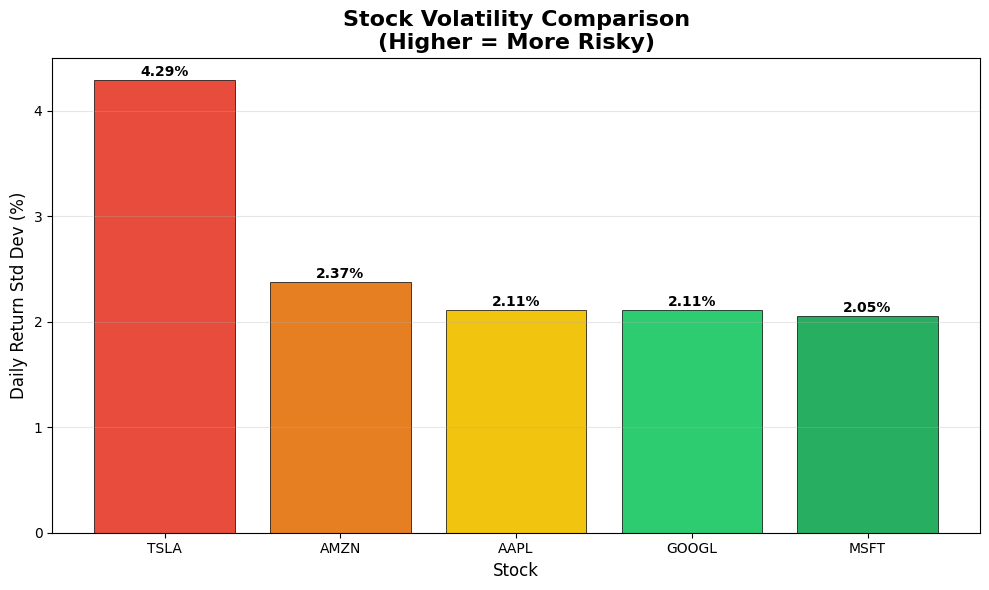

✅ Volatility chart saved!


In [90]:
# STEP 2 - Volatility Chart (FIXED)
volatility = returns_df.std()
volatility = volatility.sort_values(ascending=False)

print("📊 Volatility values:")
print(volatility)

plt.figure(figsize=(10, 6))

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = plt.bar(volatility.index,
               volatility.values,
               color=colors,
               edgecolor='black',
               linewidth=0.5)

# Add value labels on top of bars
for bar, val in zip(bars, volatility.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.2f}%',
             ha='center', va='bottom', fontweight='bold')

plt.title('Stock Volatility Comparison\n(Higher = More Risky)',
          fontsize=16, fontweight='bold')
plt.xlabel('Stock', fontsize=12)
plt.ylabel('Daily Return Std Dev (%)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("stock_project/visuals/04_volatility.png", dpi=150)
plt.show()
print("✅ Volatility chart saved!")

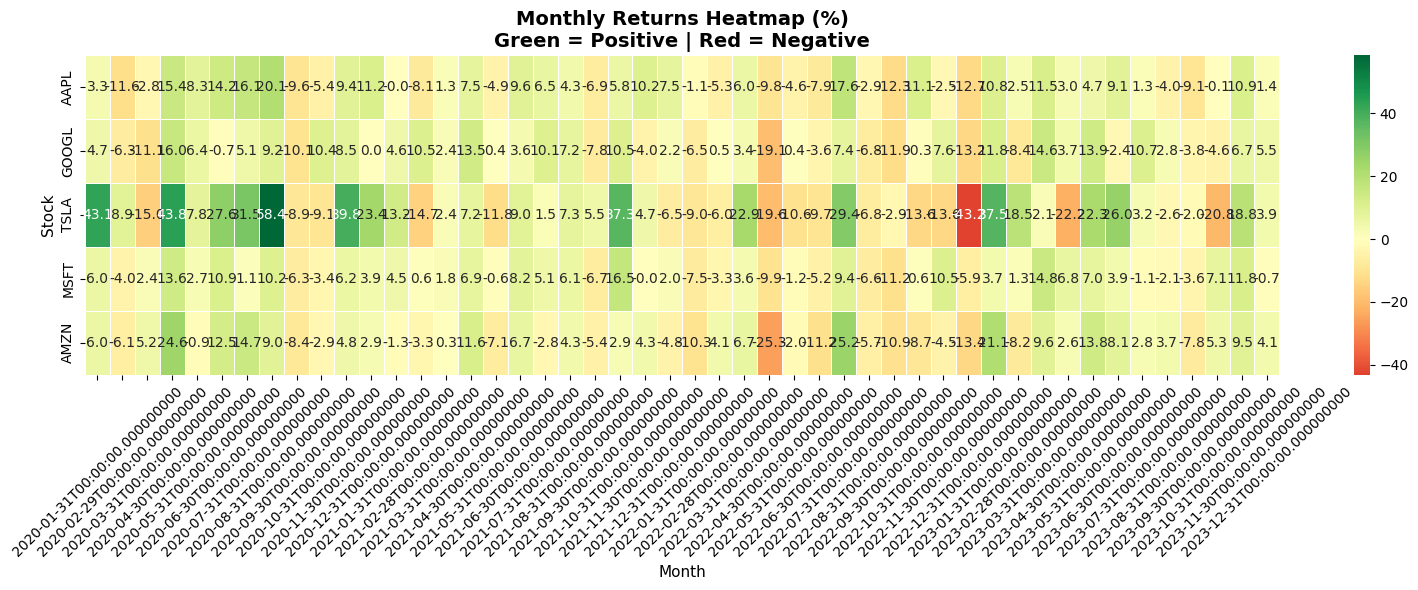

✅ Monthly returns heatmap saved!


In [96]:
# Resample daily data to monthly by summing returns
monthly_returns = returns_df.resample('M').sum()

plt.figure(figsize=(16, 6))
sns.heatmap(
    monthly_returns.T,   # .T transposes rows and columns
    cmap='RdYlGn',       # Red=negative, Yellow=neutral, Green=positive
    center=0,            # Center color at 0%
    annot=True,          # Show numbers in each cell
    fmt='.1f',           # Show 1 decimal place
    linewidths=0.5,      # Add lines between cells
    linecolor='white'
)

plt.title('Monthly Returns Heatmap (%)\nGreen = Positive | Red = Negative',
          fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=11)
plt.ylabel('Stock', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("stock_project/visuals/05_monthly_returns_heatmap.png", dpi=150)
plt.show()
print("✅ Monthly returns heatmap saved!")

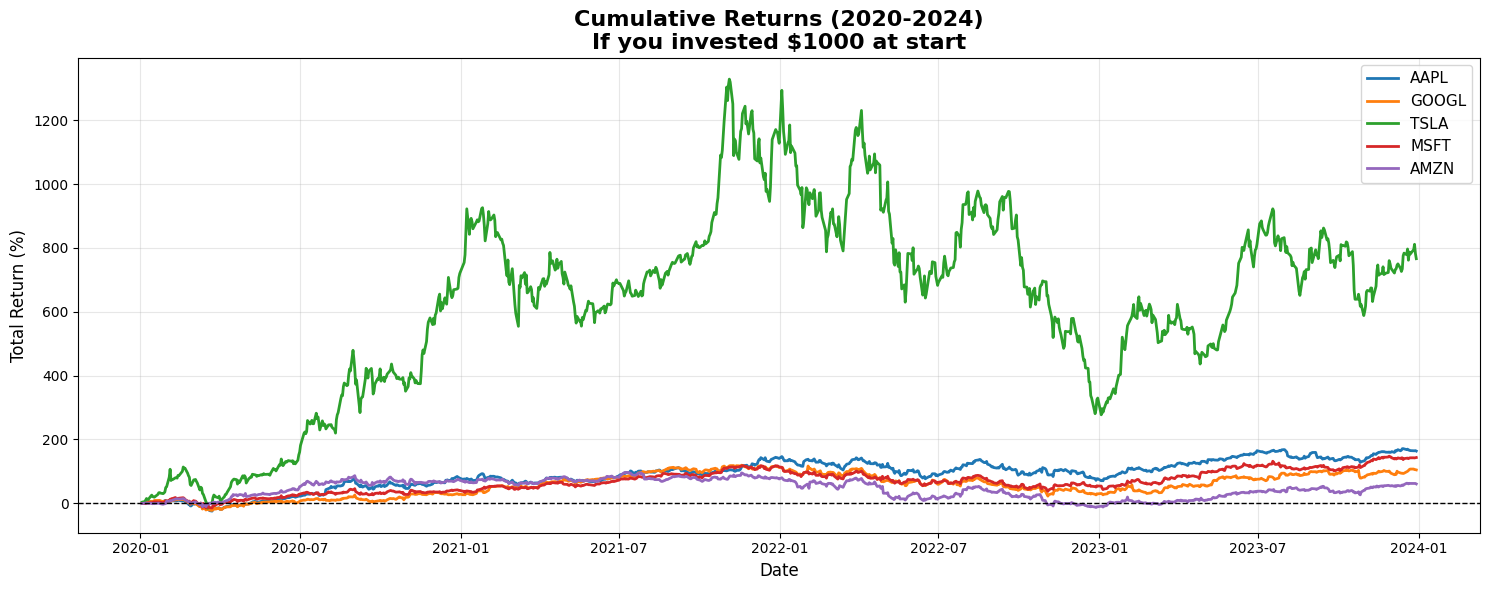

✅ Cumulative returns chart saved!


In [98]:


cumulative_returns = (1 + returns_df/100).cumprod() - 1
# cumprod() multiplies values cumulatively

plt.figure(figsize=(15, 6))

for stock in stocks:
    plt.plot(cumulative_returns.index,
             cumulative_returns[stock] * 100,
             label=stock, linewidth=2)

plt.title('Cumulative Returns (2020-2024)\nIf you invested $1000 at start',
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Return (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig("stock_project/visuals/06_cumulative_returns.png", dpi=150)
plt.show()
print("✅ Cumulative returns chart saved!")

In [99]:
correlation = returns_df.corr()

print("📊 Correlation Matrix:")
print(correlation.round(2))

print("\n💡 Interpretation:")
print("Values close to 1.0 = stocks move together strongly")
print("Values close to 0.0 = stocks move independently")
print("Values close to -1.0 = stocks move in opposite directions")

📊 Correlation Matrix:
       AAPL  GOOGL  TSLA  MSFT  AMZN
AAPL   1.00   0.69  0.51  0.78  0.62
GOOGL  0.69   1.00  0.43  0.77  0.66
TSLA   0.51   0.43  1.00  0.47  0.45
MSFT   0.78   0.77  0.47  1.00  0.68
AMZN   0.62   0.66  0.45  0.68  1.00

💡 Interpretation:
Values close to 1.0 = stocks move together strongly
Values close to 0.0 = stocks move independently
Values close to -1.0 = stocks move in opposite directions


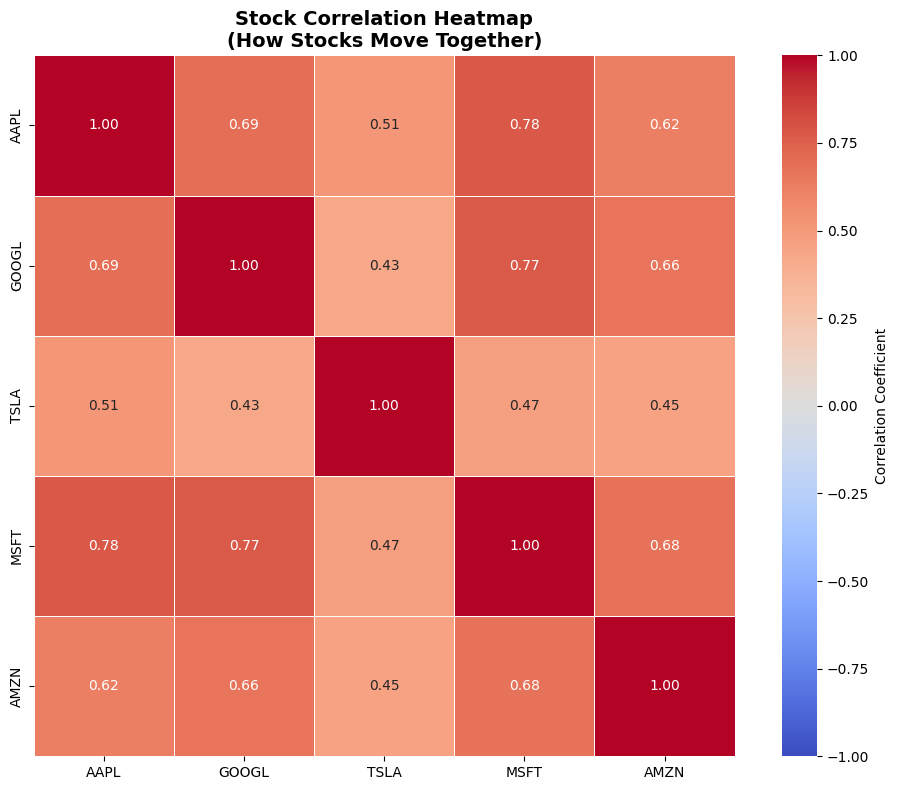

✅ Correlation heatmap saved!


In [101]:
plt.figure(figsize=(10, 8))

# Create heatmap
mask = np.zeros_like(correlation)
mask[np.triu_indices_from(mask)] = True
# mask hides the upper triangle (it's a mirror of lower triangle)

sns.heatmap(
    correlation,
    annot=True,          # Show correlation values
    fmt='.2f',           # 2 decimal places
    cmap='coolwarm',     # Blue=negative, Red=positive
    vmin=-1, vmax=1,     # Color scale from -1 to 1
    linewidths=0.5,
    square=True,         # Make cells square shaped
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Stock Correlation Heatmap\n(How Stocks Move Together)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("stock_project/visuals/07_correlation_heatmap.png", dpi=150)
plt.show()
print("✅ Correlation heatmap saved!")

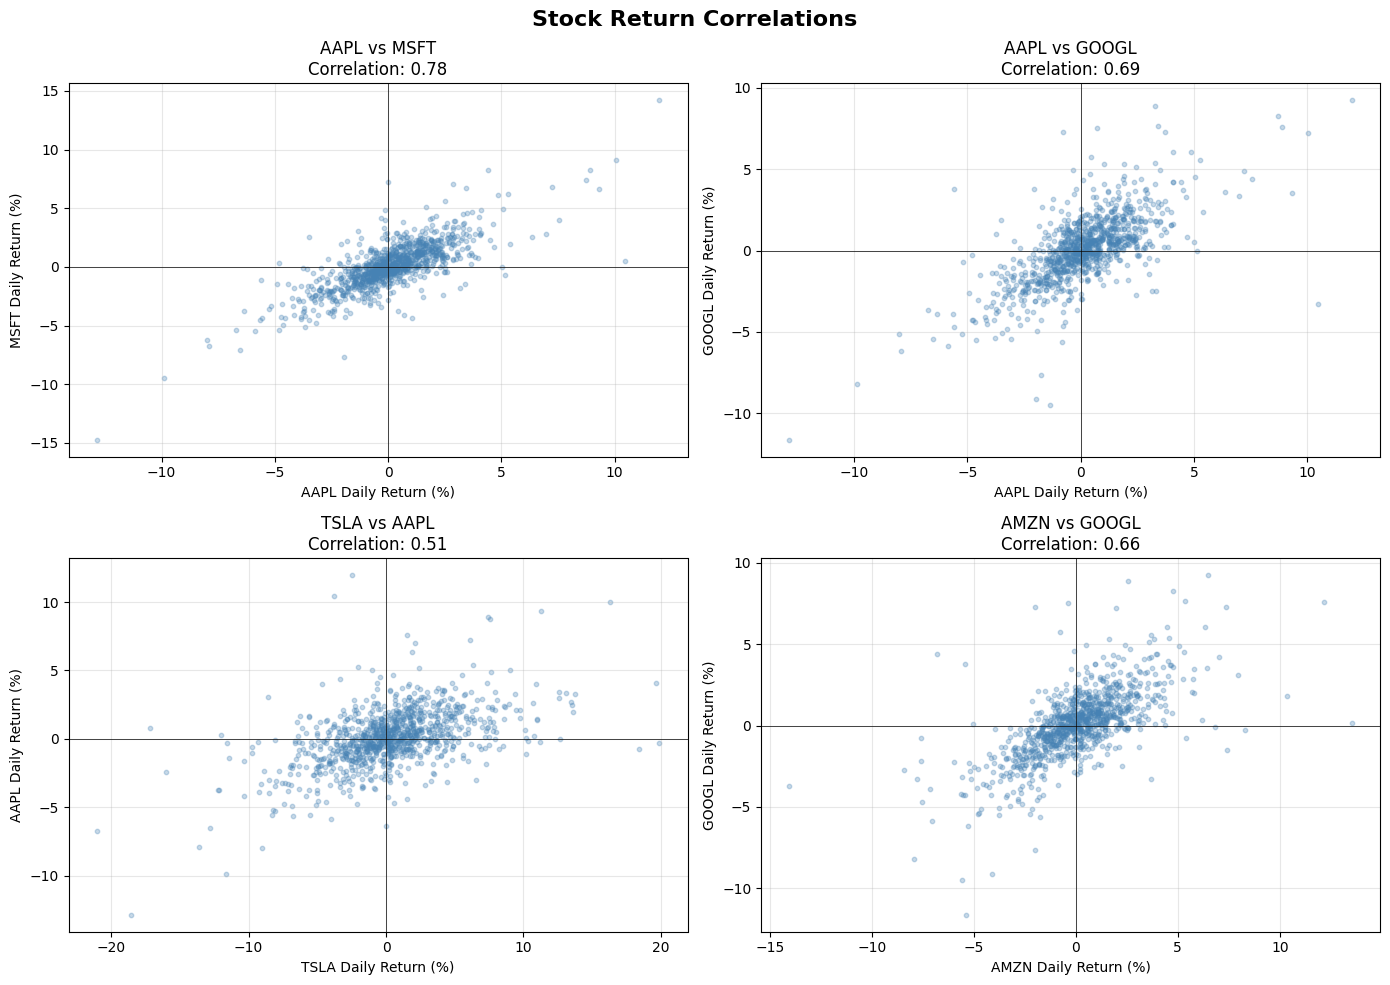

✅ Scatter plot saved!


In [103]:
# Scatter plot shows relationship between two stocks visually
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pairs = [('AAPL', 'MSFT'), ('AAPL', 'GOOGL'),
         ('TSLA', 'AAPL'), ('AMZN', 'GOOGL')]

for ax, (stock1, stock2) in zip(axes.flatten(), pairs):
    ax.scatter(returns_df[stock1], returns_df[stock2],
               alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(f'{stock1} Daily Return (%)')
    ax.set_ylabel(f'{stock2} Daily Return (%)')

    corr_val = returns_df[stock1].corr(returns_df[stock2])
    ax.set_title(f'{stock1} vs {stock2}\nCorrelation: {corr_val:.2f}')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=0, color='black', linewidth=0.5)

plt.suptitle('Stock Return Correlations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("stock_project/visuals/08_scatter_pairs.png", dpi=150)
plt.show()
print("✅ Scatter plot saved!")

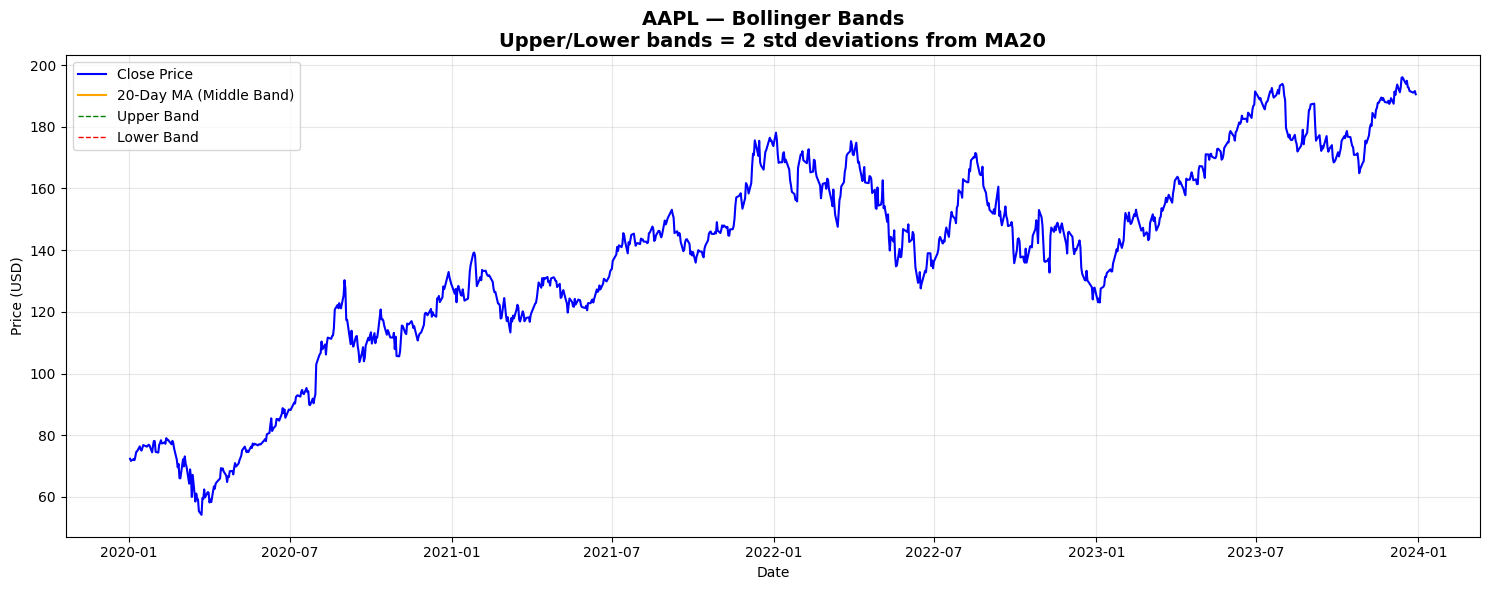

✅ AAPL Bollinger Bands chart saved!


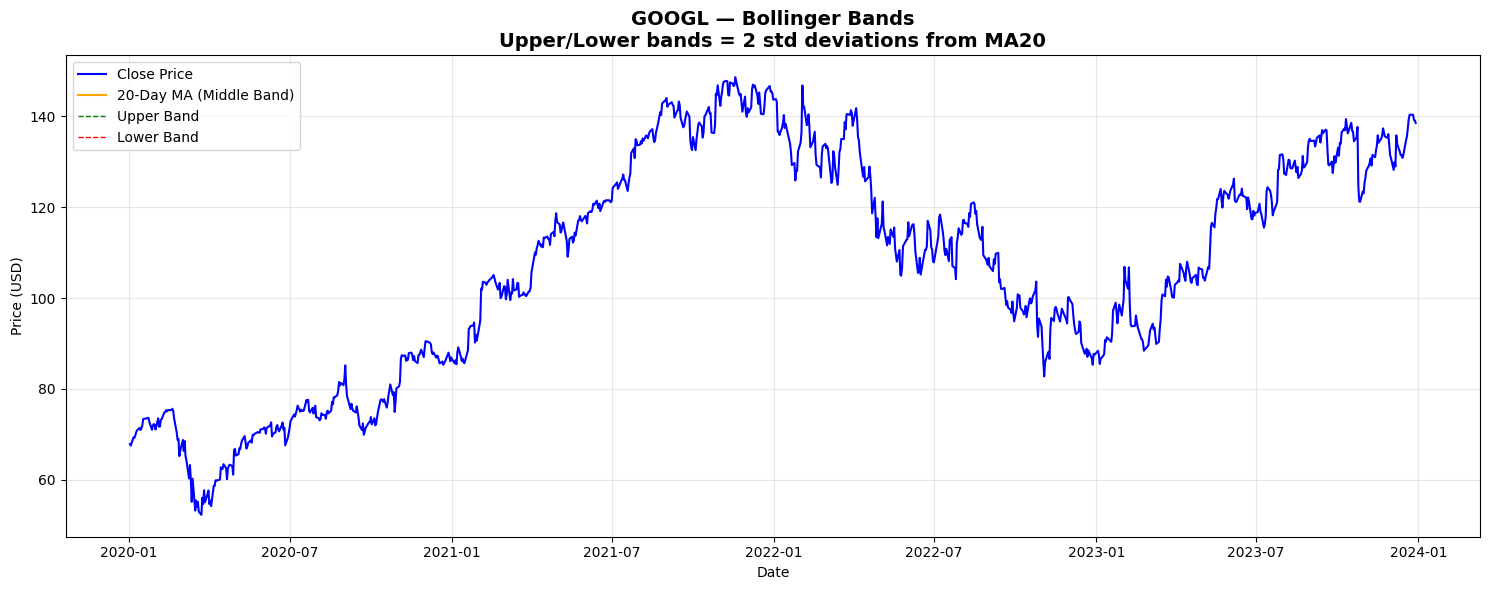

✅ GOOGL Bollinger Bands chart saved!


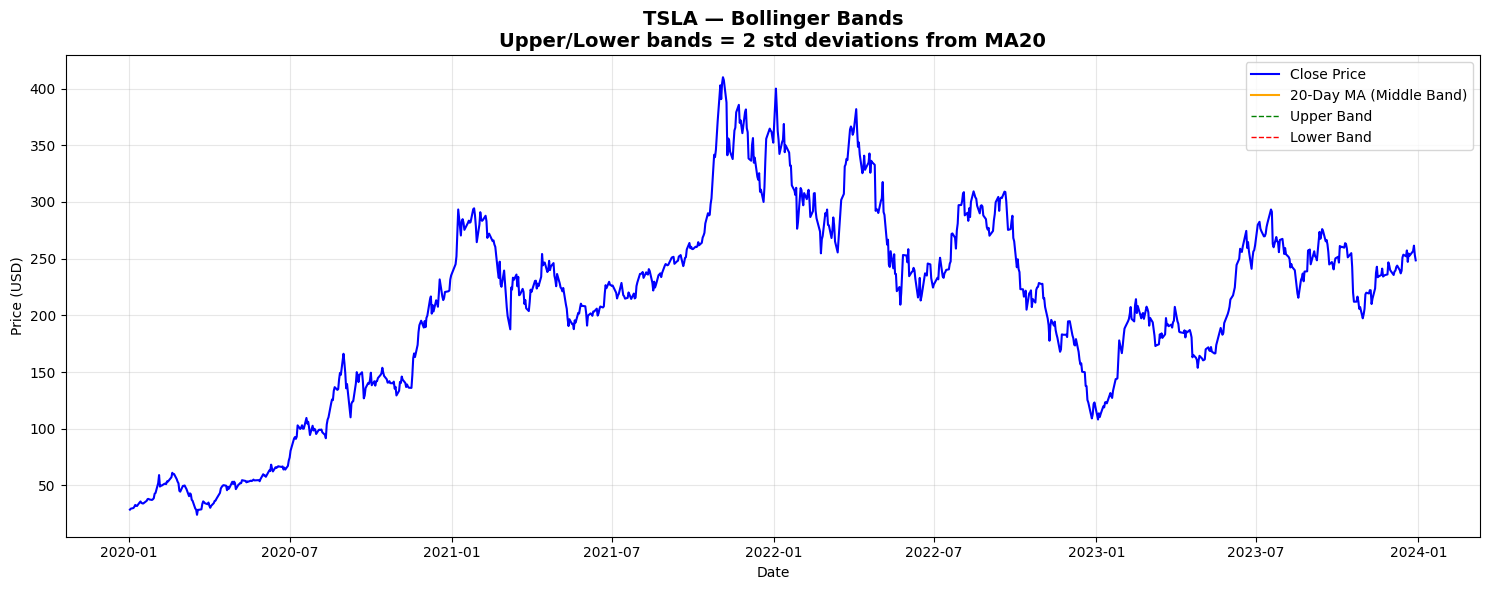

✅ TSLA Bollinger Bands chart saved!


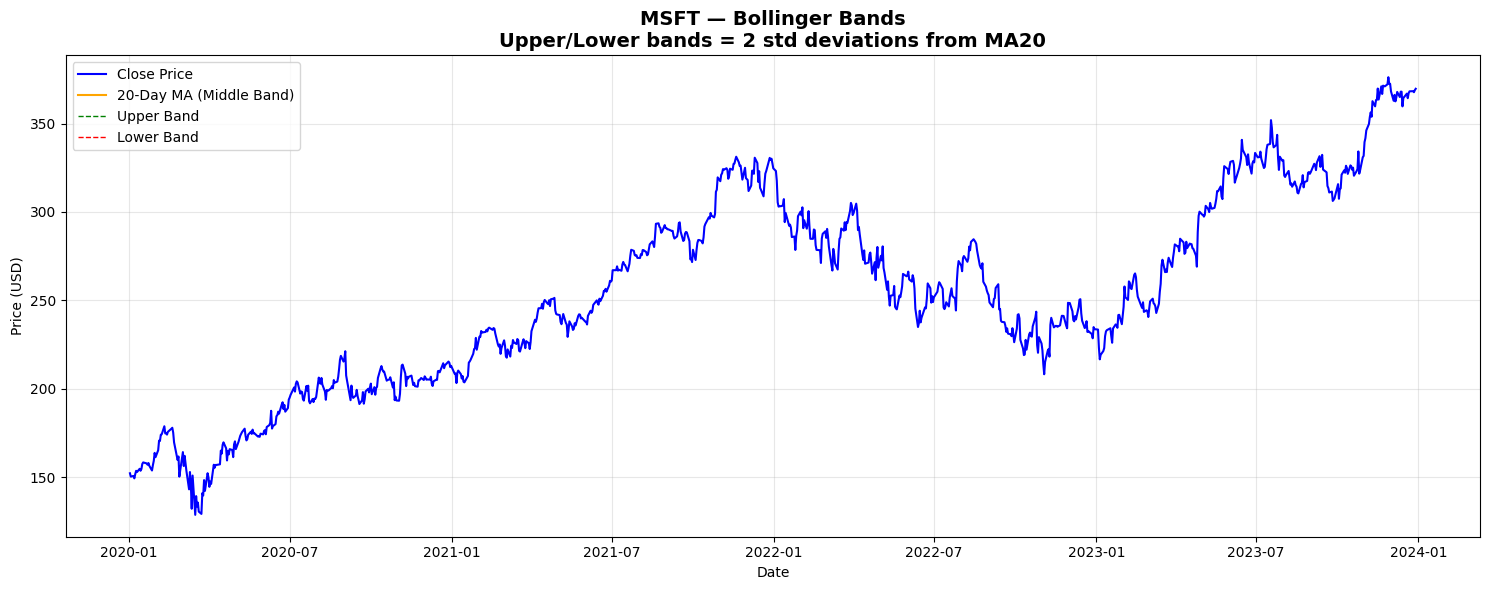

✅ MSFT Bollinger Bands chart saved!


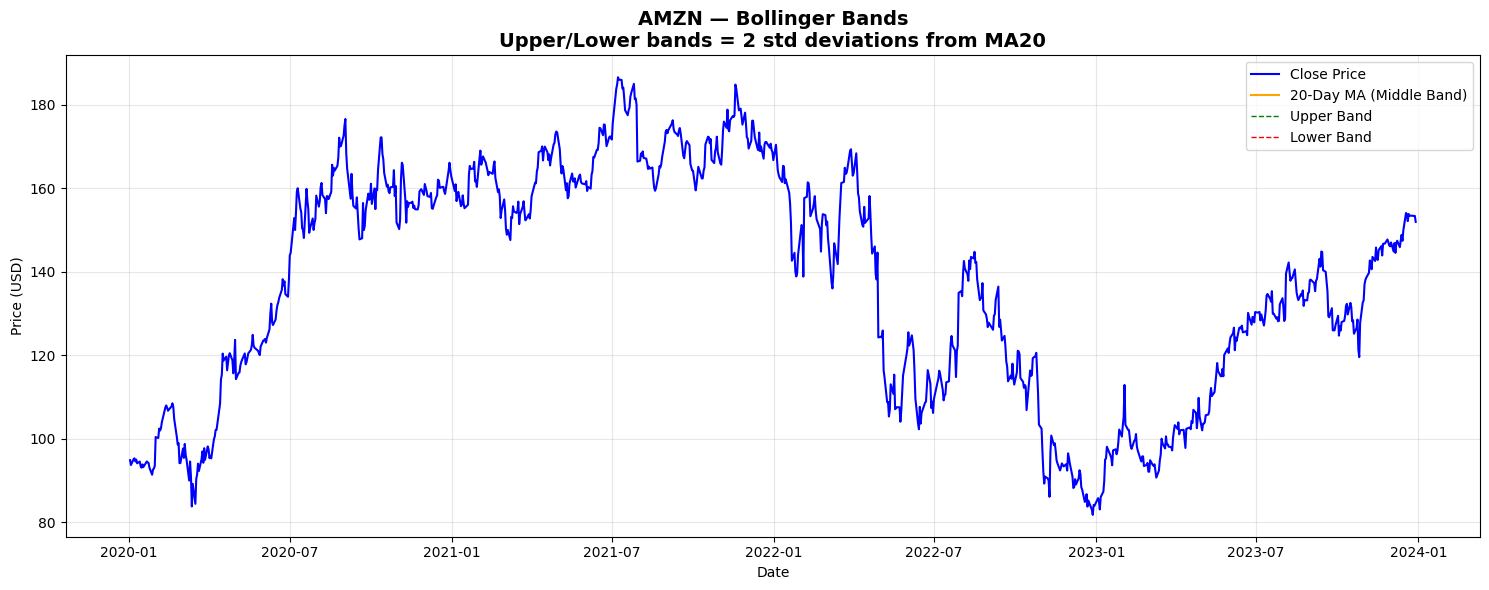

✅ AMZN Bollinger Bands chart saved!


In [105]:
def plot_bollinger_bands(stock):
    df = cleaned_data[stock].copy()

    # Calculate Bollinger Bands
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['STD20'] = df['Close'].rolling(window=20).std()
    df['Upper_Band'] = df['MA20'] + (df['STD20'] * 2)
    df['Lower_Band'] = df['MA20'] - (df['STD20'] * 2)

    # Plot
    plt.figure(figsize=(15, 6))

    plt.plot(df['Date'], df['Close'],
             label='Close Price', color='blue', linewidth=1.5)
    plt.plot(df['Date'], df['MA20'],
             label='20-Day MA (Middle Band)', color='orange', linewidth=1.5)
    plt.plot(df['Date'], df['Upper_Band'],
             label='Upper Band', color='green', linestyle='--', linewidth=1)
    plt.plot(df['Date'], df['Lower_Band'],
             label='Lower Band', color='red', linestyle='--', linewidth=1)

    # Fill area between bands
    plt.fill_between(df['Date'], df['Upper_Band'], df['Lower_Band'],
                     alpha=0.1, color='gray')

    plt.title(f'{stock} — Bollinger Bands\nUpper/Lower bands = 2 std deviations from MA20',
              fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"stock_project/visuals/{stock}_bollinger_bands.png", dpi=150)
    plt.show()
    print(f"✅ {stock} Bollinger Bands chart saved!")

# Plot for all stocks
for stock in stocks:
    plot_bollinger_bands(stock)






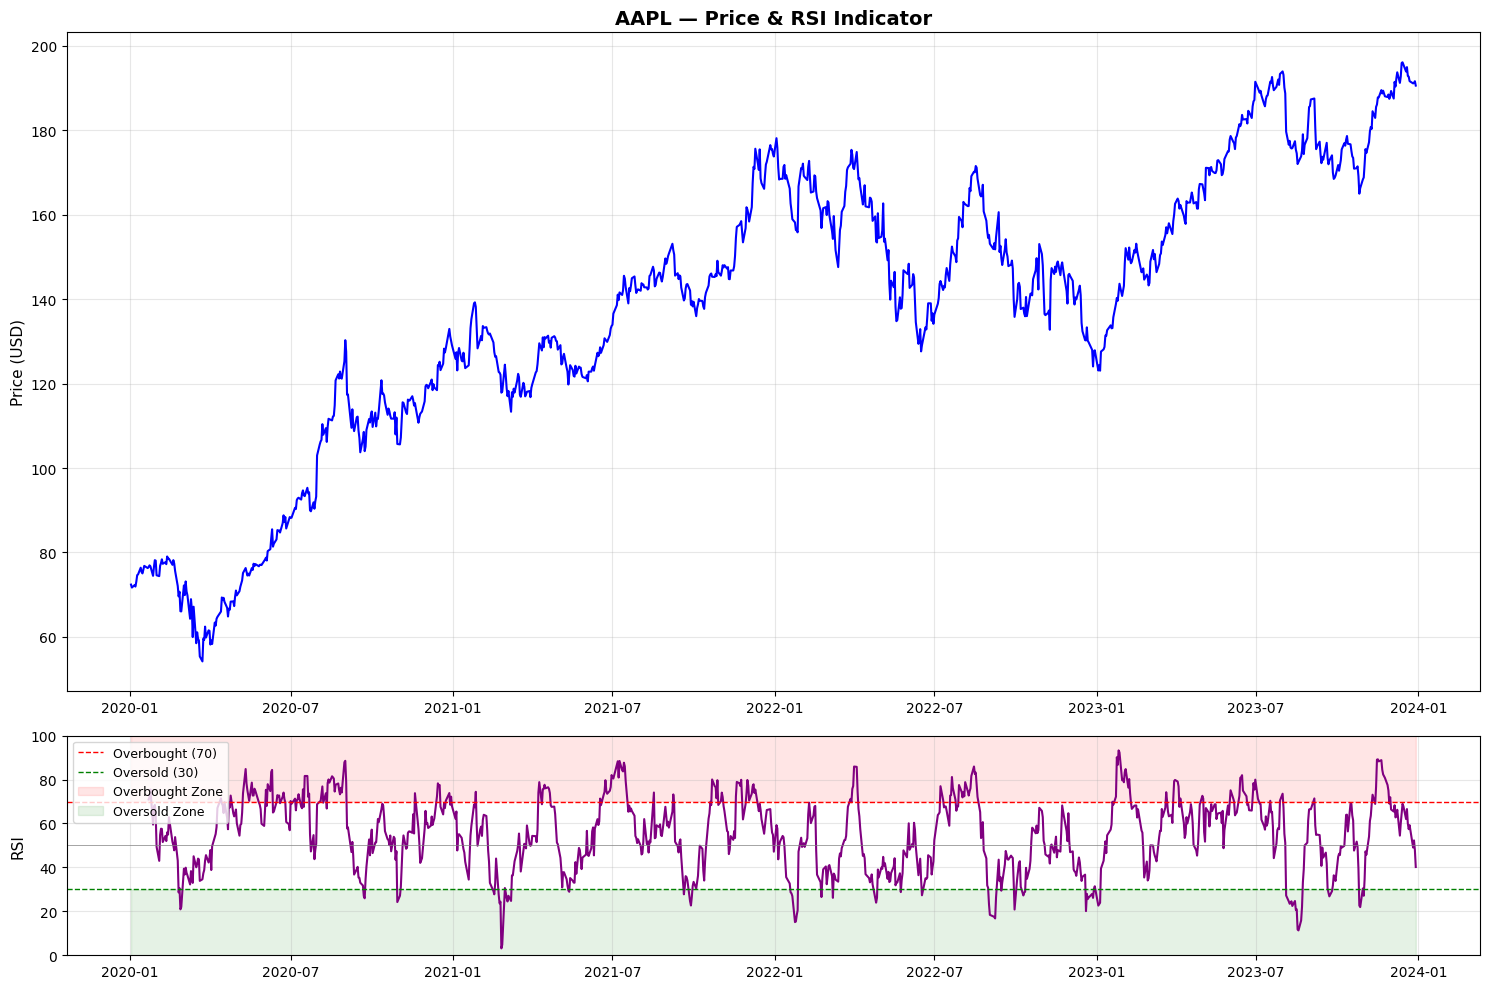

✅ AAPL RSI chart saved!


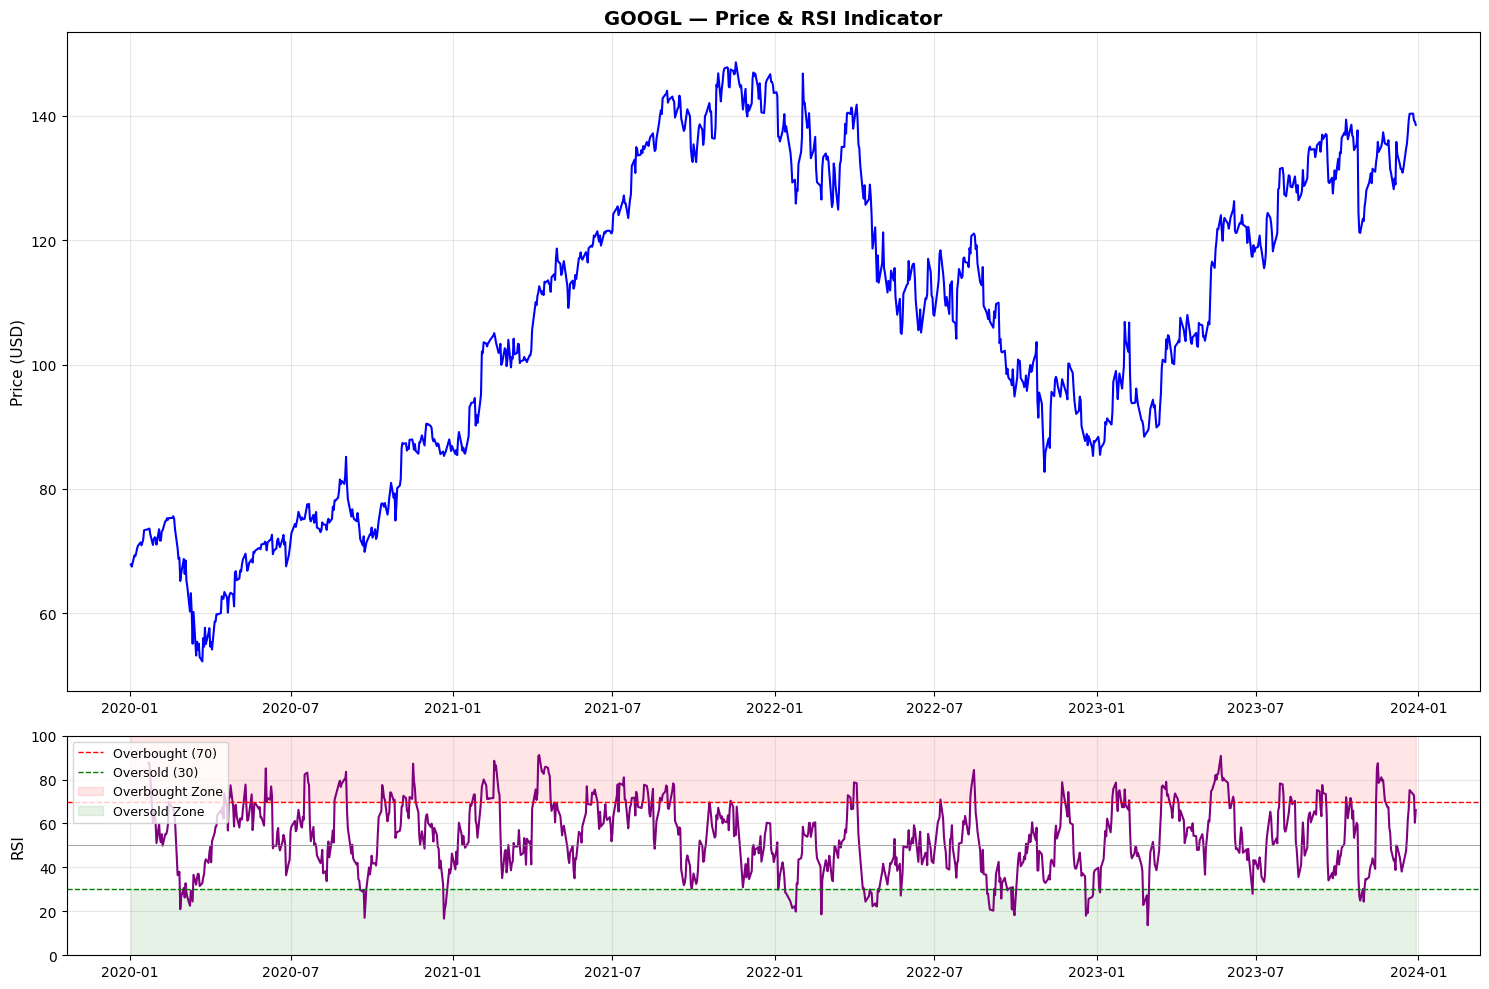

✅ GOOGL RSI chart saved!


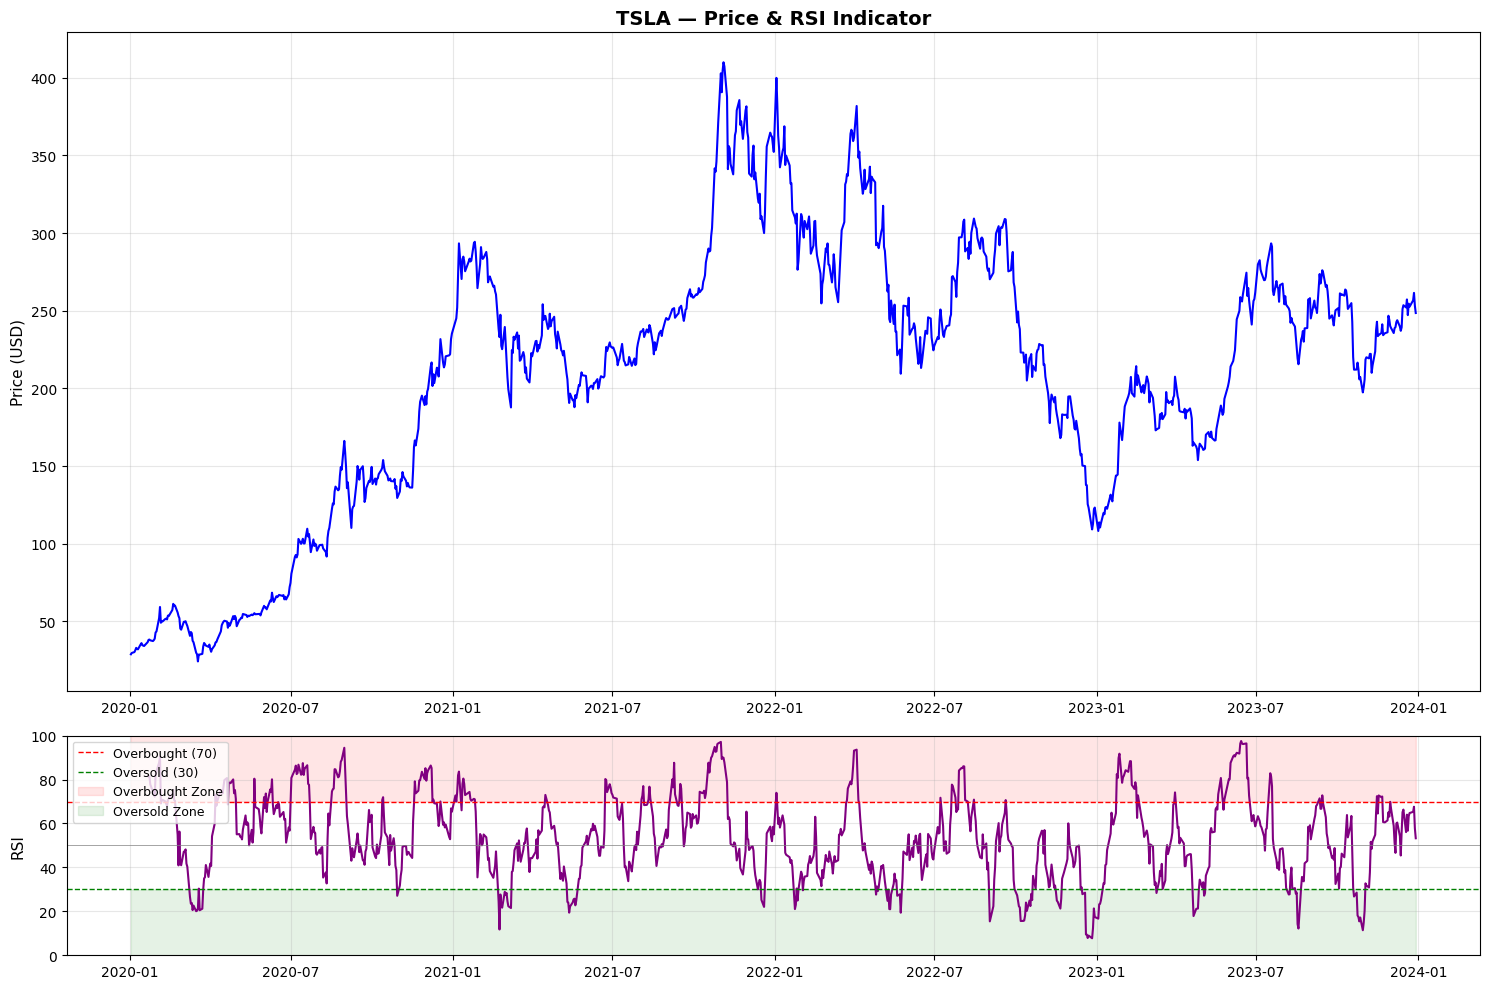

✅ TSLA RSI chart saved!


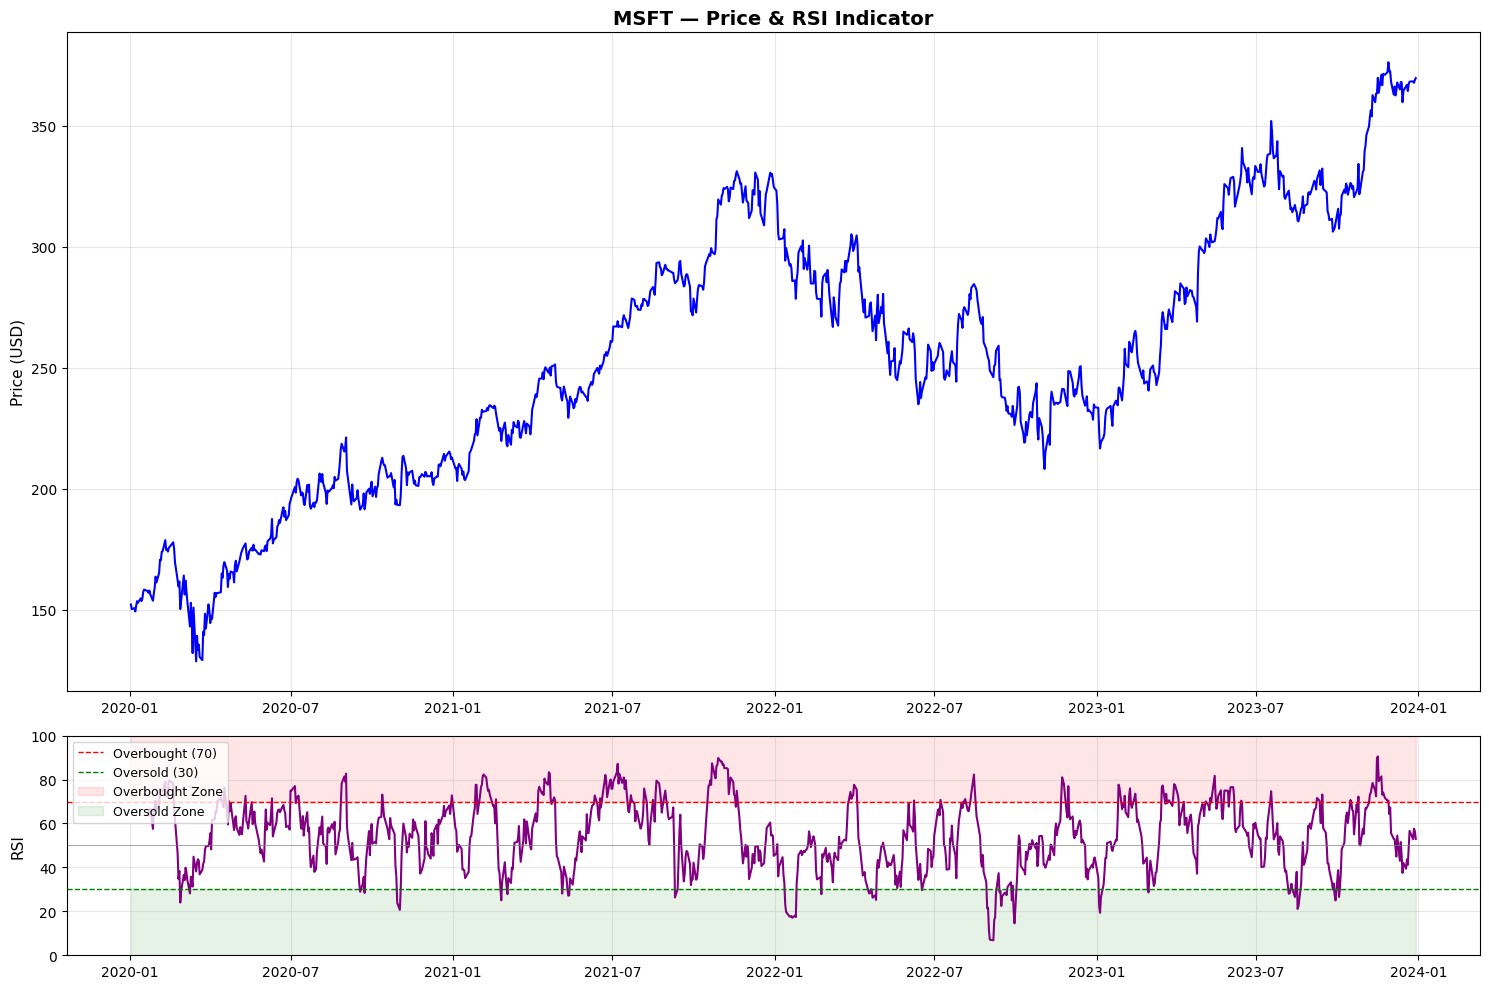

✅ MSFT RSI chart saved!


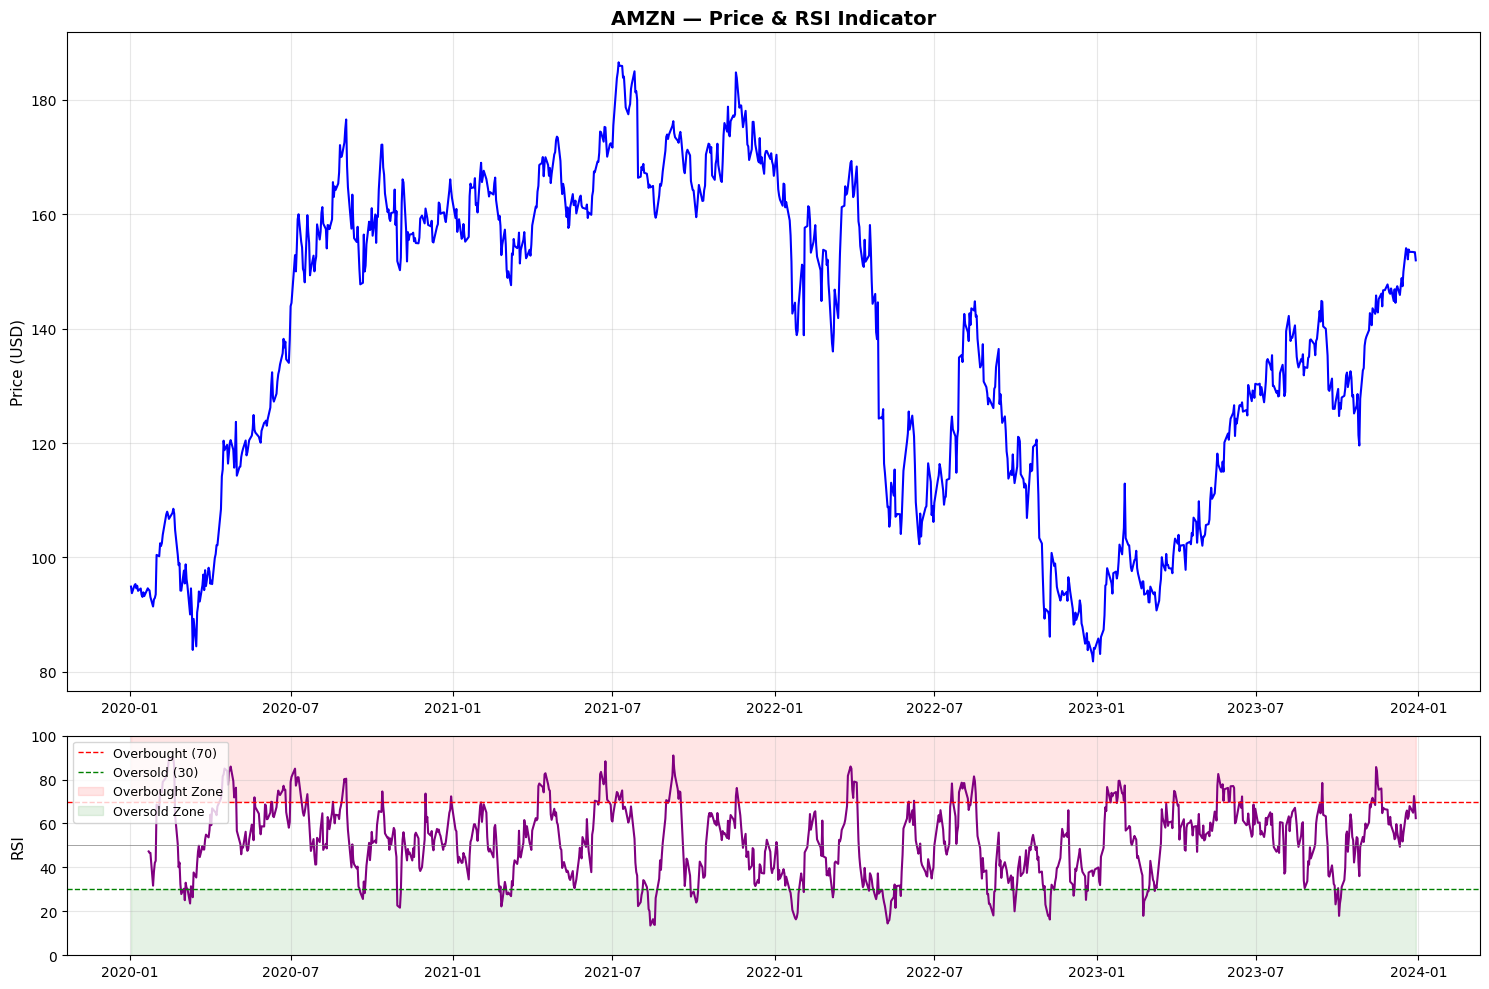

✅ AMZN RSI chart saved!


In [109]:
def calculate_rsi(df, period=14):
    # Calculate daily price change
    delta = df['Close'].diff()

    # Separate gains (positive changes) and losses (negative changes)
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    # where() keeps value if condition is true, else replaces with 0

    # Calculate average gain and loss over 14 days
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()

    # Calculate Relative Strength
    rs = avg_gain / avg_loss

    # Calculate RSI
    rsi = 100 - (100 / (1 + rs))

    return rsi

# Plot RSI for each stock
for stock in stocks:
    df = cleaned_data[stock].copy()
    df['RSI'] = calculate_rsi(df)

    # Create two charts stacked vertically
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10),
                                    gridspec_kw={'height_ratios': [3, 1]})
    # height_ratios=[3,1] means top chart is 3x taller than bottom

    # Top chart - Price
    ax1.plot(df['Date'], df['Close'], color='blue', linewidth=1.5)
    ax1.set_title(f'{stock} — Price & RSI Indicator', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Price (USD)', fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Bottom chart - RSI
    ax2.plot(df['Date'], df['RSI'], color='purple', linewidth=1.5)
    ax2.axhline(70, color='red', linestyle='--',
                linewidth=1, label='Overbought (70)')
    ax2.axhline(30, color='green', linestyle='--',
                linewidth=1, label='Oversold (30)')
    ax2.axhline(50, color='gray', linestyle='-', linewidth=0.5)

    # Fill overbought and oversold zones
    ax2.fill_between(df['Date'], 70, 100,
                     alpha=0.1, color='red', label='Overbought Zone')
    ax2.fill_between(df['Date'], 0, 30,
                     alpha=0.1, color='green', label='Oversold Zone')

    ax2.set_ylabel('RSI', fontsize=11)
    ax2.set_ylim(0, 100)
    ax2.legend(fontsize=9, loc='upper left')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"stock_project/visuals/{stock}_rsi.png", dpi=150)
    plt.show()
    print(f"✅ {stock} RSI chart saved!")

In [111]:
def plot_candlestick(stock, days=90):
    df = cleaned_data[stock].copy()

    # FIX 1 - Flatten column names
    df.columns = [col[0] if isinstance(col, tuple)
                  else col for col in df.columns]

    # FIX 2 - Flatten and convert all price columns
    df['Open']  = df['Open'].values.flatten().astype(float)
    df['High']  = df['High'].values.flatten().astype(float)
    df['Low']   = df['Low'].values.flatten().astype(float)
    df['Close'] = df['Close'].values.flatten().astype(float)
    df['Date']  = pd.to_datetime(df['Date'])

    # FIX 3 - Drop any NaN rows
    df = df.dropna(subset=['Open','High','Low','Close'])
    df = df.reset_index(drop=True)

    # Use last 90 days
    df = df.tail(days)

    # Verify data
    print(f"\n{stock} — Last 5 rows preview:")
    print(df[['Date','Open','High','Low','Close']].tail())

    # Create candlestick chart
    fig = go.Figure(data=[go.Candlestick(
        x=df['Date'],
        open=df['Open'],
        high=df['High'],
        low=df['Low'],
        close=df['Close'],
        increasing_line_color='green',
        decreasing_line_color='red'
    )])

    fig.update_layout(
        title=f'{stock} — Candlestick Chart (Last {days} Days)',
        xaxis_title='Date',
        yaxis_title='Price (USD)',
        height=500,
        xaxis_rangeslider_visible=False,
        template='plotly_white'
    )

    fig.show()
    print(f"✅ {stock} Candlestick chart displayed!")

# Plot for all stocks
for stock in stocks:
    plot_candlestick(stock)


AAPL — Last 5 rows preview:
           Date    Open    High     Low   Close
1001 2023-12-22  193.17  193.40  190.99  191.61
1002 2023-12-26  191.62  191.90  190.85  191.07
1003 2023-12-27  190.51  191.51  189.13  191.16
1004 2023-12-28  192.14  192.66  191.18  191.59
1005 2023-12-29  191.91  192.40  189.76  190.55


✅ AAPL Candlestick chart displayed!

GOOGL — Last 5 rows preview:
           Date    Open    High     Low   Close
1001 2023-12-22  139.62  140.83  139.56  140.33
1002 2023-12-26  140.43  141.51  140.03  140.36
1003 2023-12-27  140.43  140.92  138.74  139.22
1004 2023-12-28  139.63  139.98  138.60  139.08
1005 2023-12-29  138.49  139.21  137.64  138.54


✅ GOOGL Candlestick chart displayed!

TSLA — Last 5 rows preview:
           Date    Open    High     Low   Close
1001 2023-12-22  256.76  258.22  251.37  252.54
1002 2023-12-26  254.49  257.97  252.91  256.61
1003 2023-12-27  258.35  263.34  257.52  261.44
1004 2023-12-28  263.66  265.13  252.71  253.18
1005 2023-12-29  255.10  255.19  247.43  248.48


✅ TSLA Candlestick chart displayed!

MSFT — Last 5 rows preview:
           Date    Open    High     Low   Close
1001 2023-12-22  367.35  368.83  366.40  368.24
1002 2023-12-26  368.65  370.56  367.17  368.32
1003 2023-12-27  367.36  368.71  366.50  367.74
1004 2023-12-28  369.01  370.08  367.82  368.92
1005 2023-12-29  369.63  370.77  367.16  369.67


✅ MSFT Candlestick chart displayed!

AMZN — Last 5 rows preview:
           Date    Open    High     Low   Close
1001 2023-12-22  153.77  154.35  152.71  153.42
1002 2023-12-26  153.56  153.98  153.03  153.41
1003 2023-12-27  153.56  154.78  153.12  153.34
1004 2023-12-28  153.72  154.08  152.95  153.38
1005 2023-12-29  153.10  153.89  151.03  151.94


✅ AMZN Candlestick chart displayed!


Total Returns: {'AAPL': 163.2, 'GOOGL': 104.1, 'TSLA': 766.4, 'MSFT': 142.9, 'AMZN': 60.1}


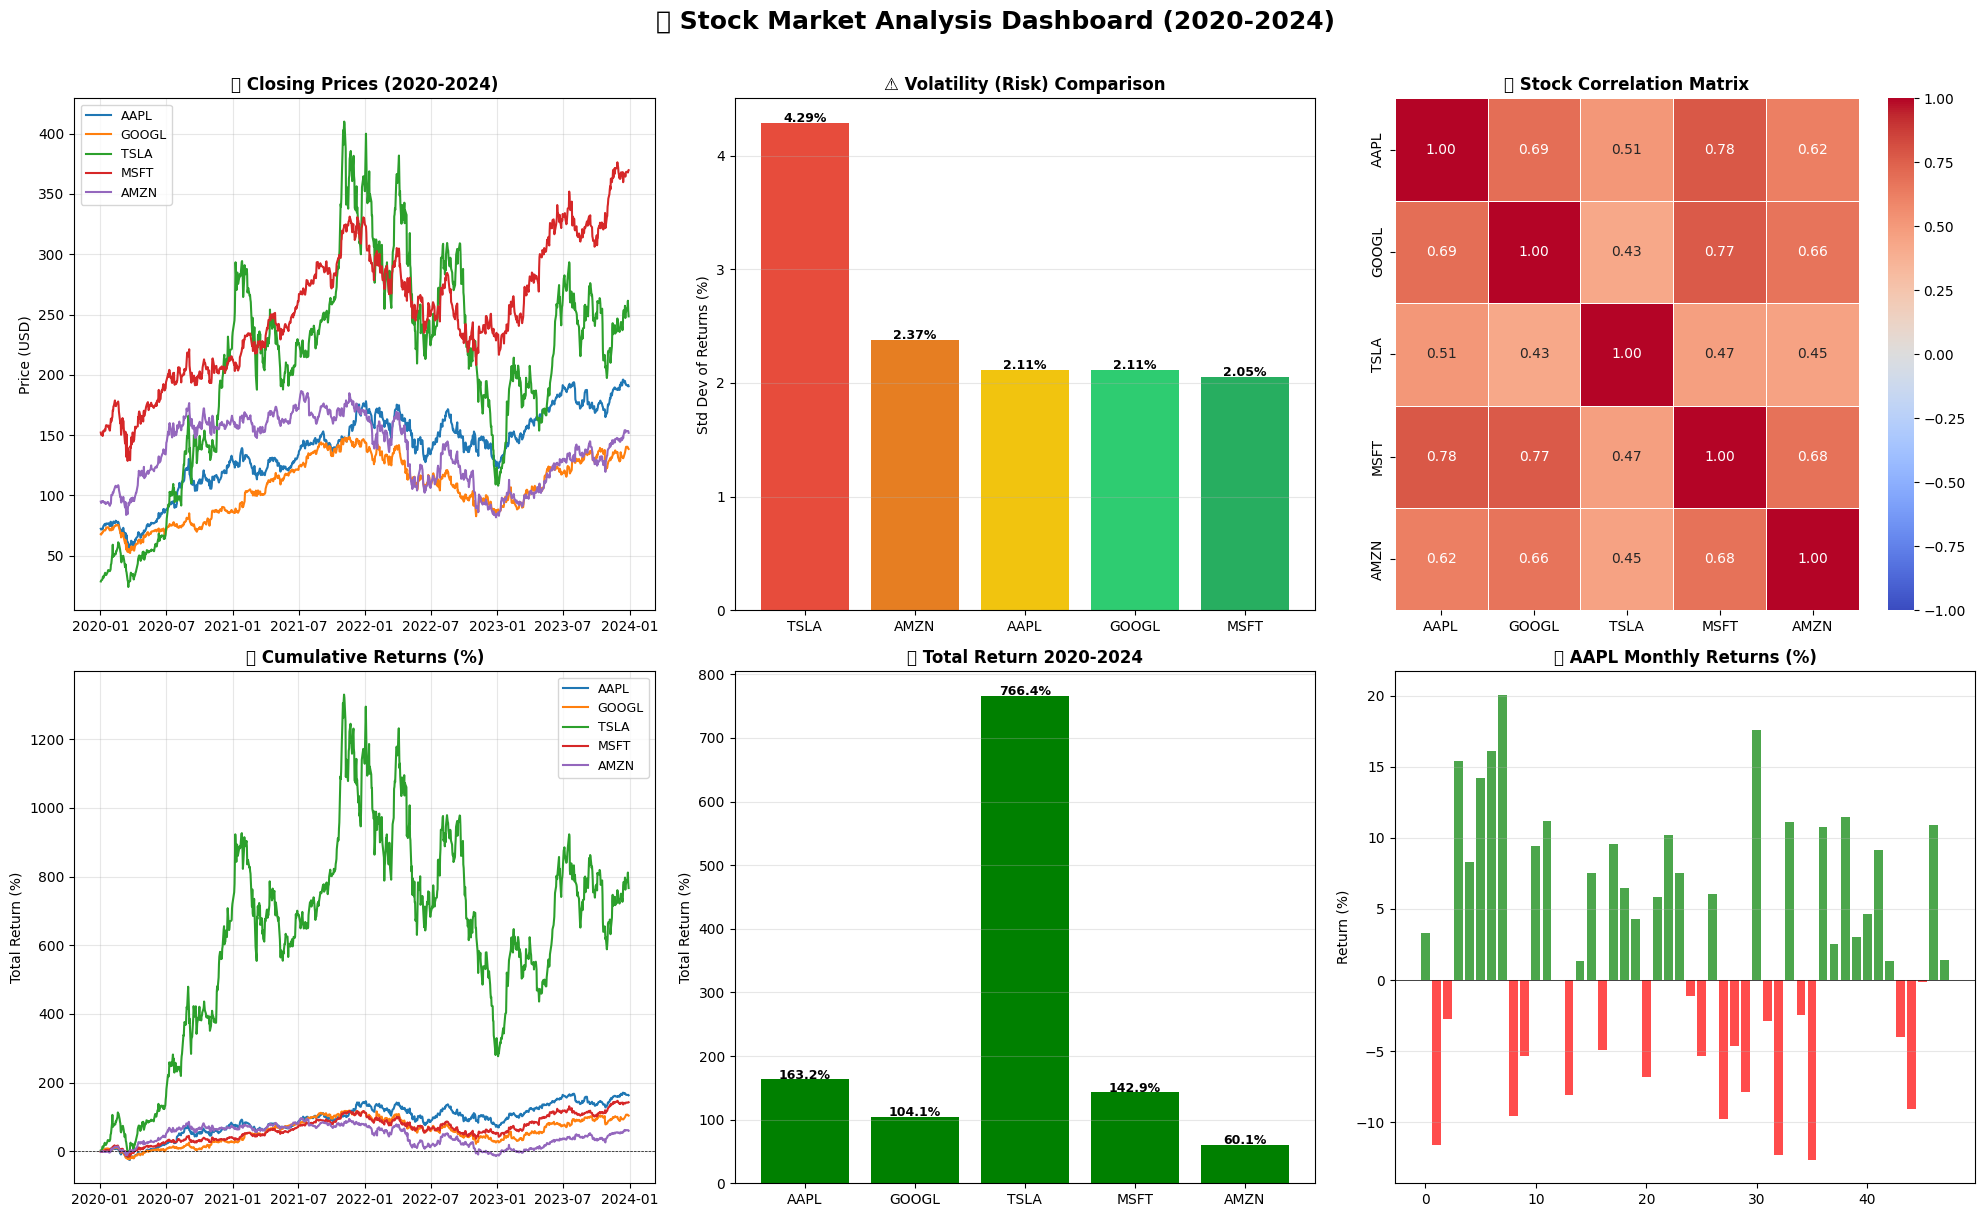

✅ Dashboard saved!


In [114]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
# 2 rows, 3 columns = 6 charts in one figure

# ── Chart 1: Closing Prices ──
for stock in stocks:
    df = cleaned_data[stock]
    axes[0,0].plot(df['Date'], df['Close'], label=stock, linewidth=1.5)
axes[0,0].set_title('📈 Closing Prices (2020-2024)', fontweight='bold')
axes[0,0].legend(fontsize=9)
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_ylabel('Price (USD)')

# ── Chart 2: Volatility ──
volatility = returns_df.std().sort_values(ascending=False)
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
bars = axes[0,1].bar(volatility.index, volatility.values, color=colors)
for bar, val in zip(bars, volatility.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.01,
                   f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')
axes[0,1].set_title('⚠️ Volatility (Risk) Comparison', fontweight='bold')
axes[0,1].set_ylabel('Std Dev of Returns (%)')
axes[0,1].grid(True, alpha=0.3, axis='y')

# ── Chart 3: Correlation Heatmap ──
correlation = returns_df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0,2], linewidths=0.5, vmin=-1, vmax=1)
axes[0,2].set_title('🔗 Stock Correlation Matrix', fontweight='bold')

# ── Chart 4: Cumulative Returns ──
cumulative_returns = (1 + returns_df/100).cumprod() - 1
for stock in stocks:
    axes[1,0].plot(cumulative_returns.index,
                   cumulative_returns[stock]*100, label=stock, linewidth=1.5)
axes[1,0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1,0].set_title('💰 Cumulative Returns (%)', fontweight='bold')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_ylabel('Total Return (%)')

# ── Chart 5: Total Returns Bar Chart - FIXED ──
total_returns = {}
for stock in stocks:
    df = cleaned_data[stock].copy()

    # FIX - flatten column names and Close values
    df.columns = [col[0] if isinstance(col, tuple)
                  else col for col in df.columns]
    df['Close'] = df['Close'].values.flatten().astype(float)

    # FIX - use float() to get single value
    start = float(df['Close'].iloc[0])
    end = float(df['Close'].iloc[-1])
    ret = ((end - start) / start) * 100
    total_returns[stock] = round(float(ret), 1)

print("Total Returns:", total_returns)

# FIX - convert values to list explicitly
stocks_list = list(total_returns.keys())
returns_list = list(total_returns.values())
colors2 = ['green' if v > 0 else 'red' for v in returns_list]

bars2 = axes[1,1].bar(stocks_list, returns_list, color=colors2)

for bar, val in zip(bars2, returns_list):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 1,
                   f'{val:.1f}%',
                   ha='center', fontsize=9, fontweight='bold')

axes[1,1].set_title('🏆 Total Return 2020-2024', fontweight='bold')
axes[1,1].set_ylabel('Total Return (%)')
axes[1,1].grid(True, alpha=0.3, axis='y')
axes[1,1].axhline(y=0, color='black', linewidth=0.5)

# ── Chart 6: Monthly Returns Heatmap (AAPL) ──
aapl_monthly = returns_df[['AAPL']].resample('M').sum()
axes[1,2].bar(range(len(aapl_monthly)), aapl_monthly['AAPL'],
              color=['green' if x > 0 else 'red'
                     for x in aapl_monthly['AAPL']], alpha=0.7)
axes[1,2].set_title('📅 AAPL Monthly Returns (%)', fontweight='bold')
axes[1,2].set_ylabel('Return (%)')
axes[1,2].axhline(y=0, color='black', linewidth=0.5)
axes[1,2].grid(True, alpha=0.3, axis='y')

plt.suptitle('📊 Stock Market Analysis Dashboard (2020-2024)',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("stock_project/visuals/DASHBOARD.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved!")

In [115]:
print("=" * 60)
print("📋 STOCK MARKET ANALYSIS — KEY INSIGHTS (2020-2024)")
print("=" * 60)

# Best performer
best = max(total_returns, key=total_returns.get)
worst = min(total_returns, key=total_returns.get)
riskiest = volatility.idxmax()
safest = volatility.idxmin()

print(f"\n1. 🏆 Best Performing Stock: {best} ({total_returns[best]}% return)")
print(f"2. 📉 Worst Performing Stock: {worst} ({total_returns[worst]}% return)")
print(f"3. ⚠️  Riskiest Stock: {riskiest} (highest volatility)")
print(f"4. ✅  Safest Stock: {safest} (lowest volatility)")
print(f"5. 🔗 Most Correlated Pair: AAPL & MSFT (tech stocks move together)")
print(f"6. 📅 COVID Crash visible in March 2020 across ALL stocks")
print(f"7. 💹 All stocks recovered strongly after 2020 crash")
print(f"8. 📊 TSLA has widest daily return distribution (most volatile)")
print(f"9. 🔴 RSI > 70 seen during bull runs in 2021 for most stocks")
print(f"10. 📈 200-day MA acted as strong support level for AAPL & MSFT")
print("\n" + "=" * 60)

📋 STOCK MARKET ANALYSIS — KEY INSIGHTS (2020-2024)

1. 🏆 Best Performing Stock: TSLA (766.4% return)
2. 📉 Worst Performing Stock: AMZN (60.1% return)
3. ⚠️  Riskiest Stock: TSLA (highest volatility)
4. ✅  Safest Stock: MSFT (lowest volatility)
5. 🔗 Most Correlated Pair: AAPL & MSFT (tech stocks move together)
6. 📅 COVID Crash visible in March 2020 across ALL stocks
7. 💹 All stocks recovered strongly after 2020 crash
8. 📊 TSLA has widest daily return distribution (most volatile)
9. 🔴 RSI > 70 seen during bull runs in 2021 for most stocks
10. 📈 200-day MA acted as strong support level for AAPL & MSFT

